# Chartbook — every series, plotted

A companion to [`derivation.ipynb`](derivation.ipynb). That notebook explains
*how* each series was built; this one *shows* each one, so the construction can
be eyeballed rather than taken on trust.

One chart per series, organised **country → category → series**, then a
separate section reconciling our totals against the IMF WEO.

Everything is read from [`../deliverables/`](../deliverables) and nothing is
recomputed.

## How to read a chart

Each chart plots one series in **levels, millions of national currency**, with
the year on the x-axis.

| element | meaning |
|---|---|
| <span style="color:#2a78d6">**solid blue**</span> | the `strict` variant — official published sources only |
| <span style="color:#eb6834">**dashed orange**</span> | the `maximum_extension` variant — strict plus proxy, composite and partial-coverage legs. Drawn only where it goes further than strict; where you see one line, the two coincide exactly |
| grey shading | projection years (after the last outturn) |
| dotted vertical rules | **seams** — a year where the source or the construction method changes. This is where to look for steps, kinks and level shifts |
| caption under the chart | the ordered recipe: span, how the segment was made, source, grade |

Two things to keep in mind while scanning:

* **The y-axis is not zeroed.** These are levels over decades, autoscaled, so a
  wobble that looks dramatic may be a fraction of a percent. Read the axis.
* **A seam without a visible kink is the good case.** Every stitch is a growth
  rate chained onto an anchor, so a clean join should be invisible; a step at a
  dotted line is the thing worth asking about.

## Series that do not fit this schema

You asked to be told. Ten things sit awkwardly in a flat country → category →
series layout, and all ten are visible in the charts once you know to look:

1. **Every series is really two series.** `strict` and `maximum_extension` are
   separate constructions, so each chart carries up to two lines. They agree
   exactly wherever both exist — 2,724 year-values, zero disagreement — and the
   orange line appears only where the maximum variant reaches further. It
   reaches further at **both ends**: a longer forecast, and (for GBR R02,
   FRA R04/R06, DEU R04/R06) a longer *backward* leg where the backward source
   grades C.
2. **`GF01_X` is an identity, not a source.** It is `GF01 − GF01_7`, and by
   construction it is never forecast. Its chart always stops at the last
   outturn, and it is the only expenditure line that does.
3. **`TE` and `TR` are totals, not members of the 66 line series.** They live
   in the same files and are charted at the end of each category, but they are
   envelopes: they constrain the lines and carry no stitched forecast path of
   their own.
4. **The balance ledger is a different kind of object.** Its TR and TE are the
   *balance anchor's own published totals*, not sums of the lines charted above
   them; NLB, NI and PB are derived from those. It is **outturn-only** — there
   are no projection years at all — so those five charts stop earlier than the
   tree charts do. And the two variants are identical in the ledger, so every
   ledger chart is a single line.
5. **The UK therefore has two different TE numbers**, from two different ONS
   tables. That is expected, not a bug, and §5 charts the difference: under
   0.02% until 2023, 0.51% in 2024. France differs by at most 0.055%, Germany
   by nothing.
6. **The WEO level comparison only exists over the overlap years.** Our ledger
   has no forecast, so the "ours vs WEO" charts in §4 are history-only and stop
   at 2024/2025. There is no honest level chart of the forecast side.
7. **`weo_reconciliation.csv` is not a time series at all.** It holds
   contributions in percentage points of GDP, keyed by WEO vintage, base year
   and horizon. Only one of its components — `explained_share` — can be plotted
   against time, and §4.4 does that instead of a level comparison.
8. **Horizon asymmetry.** FRA and DEU `GF07`, `GF09` and `GF10` run to 2070 and
   `GF01_7` to 2036, against a history starting in 1991 or 1995. Those charts
   are mostly shaded. Read the unshaded part as data and the rest as somebody
   else's projection.
9. **Some series have interior gaps.** Net interest and the primary balance are
   blank in 16 ledger rows — the early UK years and 2025 everywhere — because
   one of the two interest legs does not reach. The line breaks rather than
   interpolating across the hole.
10. **`pct_gdp` does not span what levels span.** GDP is missing for 60 rows —
    France before 1975, where Eurostat's GDP series starts but the OECD tax
    series does not. This chartbook plots levels, so it is unaffected; a
    %-of-GDP chartbook would lose France's first decade.

In [1]:
from pathlib import Path
from textwrap import fill

import matplotlib.pyplot as plt
import pandas as pd

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents]
            if (p / "deliverables" / "series_catalogue.csv").exists())
DELIV = ROOT / "deliverables"
load = lambda n: pd.read_csv(DELIV / f"{n}.csv")

EXPENDITURE = load("expenditure_cofog")
REVENUE = load("revenue_esa")
TREE = pd.concat([EXPENDITURE, REVENUE], ignore_index=True)
LEDGER = load("balance_ledger")
LEVELS = load("weo_levels_bridge")
RECON = load("weo_reconciliation")
CATALOGUE = load("series_catalogue")

LATEST = sorted(LEVELS.weo_vintage.dropna().unique())[-1]
NAME = dict(zip(CATALOGUE.iso3, CATALOGUE.country))

# Categorical slots 1-3 of the validated palette, assigned by entity and never
# reused: blue is always our strict series, orange always the maximum
# extension, aqua always the IMF WEO. Line style repeats the distinction so
# identity never rests on colour alone.
BLUE, ORANGE, AQUA = "#2a78d6", "#eb6834", "#1baf7a"
INK, MUTED, AXIS = "#0b0b0b", "#898781", "#c3c2b7"
SURFACE, SHADE = "#fcfcfb", "#eceae4"

plt.rcParams.update({
    "figure.figsize": (7.2, 2.9), "figure.dpi": 90,
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE,
    "savefig.facecolor": SURFACE,
    "axes.edgecolor": AXIS, "axes.labelcolor": INK, "axes.titlecolor": INK,
    "axes.titlesize": 11, "axes.titleweight": "bold", "axes.titlelocation": "left",
    "axes.labelsize": 9, "axes.spines.top": False, "axes.spines.right": False,
    "xtick.color": MUTED, "ytick.color": MUTED,
    "xtick.labelsize": 8.5, "ytick.labelsize": 8.5,
    "grid.color": AXIS, "grid.alpha": 0.45, "grid.linewidth": 0.6,
    "legend.frameon": False, "legend.fontsize": 8.5,
    "lines.linewidth": 2,
})


def thousands(ax):
    """Levels run to seven figures; unseparated tick labels are unreadable."""
    ax.yaxis.set_major_formatter(
        plt.matplotlib.ticker.FuncFormatter(lambda v, _: f"{v:,.0f}"))


def _seams(g):
    """Years where the source or the construction method changes."""
    g = g.sort_values("year")
    key = list(zip(g.observation_type, g.source_id.fillna("")))
    return [int(y) for (a, b), y in zip(zip(key, key[1:]), g.year[1:]) if a != b]


def _caption(iso3, line_code):
    row = CATALOGUE.query("iso3 == @iso3 and line_code == @line_code").iloc[0]
    text = str(row.recipe_maximum_extension).replace(" | ", "  ·  ")
    out = fill(f"recipe: {text}", 108, subsequent_indent="        ")
    if isinstance(row.reason_series_ends, str):
        out += "\n" + fill(f"ends:   {row.reason_series_ends}", 108,
                           subsequent_indent="        ")
    return out


def chart(iso3, line_code, caption=True):
    """One series, both variants, with its seams and projection region."""
    g = TREE.query("iso3 == @iso3 and line_code == @line_code")
    strict = g.query("variant == 'strict'").sort_values("year")
    mx = g.query("variant == 'maximum_extension'").sort_values("year")
    label = g.line_label.iloc[0]
    actual = g.query("basis == 'actual'").year.max()

    fig, ax = plt.subplots()
    if len(mx) > len(strict):
        ax.plot(mx.year, mx.value_lcu_mn, color=ORANGE, ls="--",
                label="maximum_extension")
    ax.plot(strict.year, strict.value_lcu_mn, color=BLUE, label="strict")
    if mx.year.max() > actual:
        ax.axvspan(actual, mx.year.max(), color=SHADE, zorder=0, lw=0)
    for year in _seams(mx):
        ax.axvline(year, color=MUTED, ls=":", lw=0.9, alpha=0.8, zorder=1)

    ax.set_title(f"{NAME[iso3]} · {line_code} — {label}")
    ax.set_ylabel(f"{g.currency.iloc[0]} mn")
    ax.grid(axis="y")
    ax.margins(x=0.01)
    thousands(ax)
    if len(mx) > len(strict):
        ax.legend(loc="upper left")
    fig.tight_layout()
    plt.show()
    if caption:
        print(_caption(iso3, line_code))


def ledger_chart(iso3, quantity):
    """One balance-ledger quantity. Outturn only; the variants are identical."""
    g = LEDGER.query("iso3 == @iso3 and variant == 'strict'").sort_values("year")
    col = f"{quantity.lower()}_lcu_mn"
    meaning = {"TR": "total revenue (balance anchor's own total)",
               "TE": "total expenditure (balance anchor's own total)",
               "NLB": "net lending (+) / net borrowing (-) = TR - TE",
               "NI": "net interest = GF01_7 - R07",
               "PB": "primary balance = NLB + NI"}[quantity]

    fig, ax = plt.subplots()
    ax.plot(g.year, g[col], color=BLUE)
    if (g[col] < 0).any():
        ax.axhline(0, color=AXIS, lw=1, zorder=0)
    ax.set_title(f"{NAME[iso3]} · ledger {quantity} — {meaning}")
    ax.set_ylabel(f"{g.currency.iloc[0]} mn")
    ax.grid(axis="y")
    ax.margins(x=0.01)
    thousands(ax)
    fig.tight_layout()
    plt.show()
    missing = g[g[col].isna()].year.tolist()
    print(f"outturn years {int(g.year.min())}-{int(g.year.max())};"
          f" source {g.source_id.iloc[0]}"
          + (f"; no value for {missing}" if missing else ""))


WEO_Q = {
    "revenue": ("tr_ours_mn", "tr_weo_mn", "gap_tr_pct_te",
                "total revenue", "WEO GGR"),
    "expenditure": ("te_ours_mn", "te_weo_mn", "gap_te_pct_te",
                    "total expenditure", "WEO GGX"),
    "nlb": ("nlb_ours_mn", "nlb_weo_mn", "gap_nlb_pct_te",
            "net lending / borrowing", "WEO GGXCNL"),
}


def weo_chart(iso3, quantity, vintage=None):
    """Ours against the IMF WEO, level and gap, over the overlap years."""
    vintage = vintage or LATEST
    ours_col, weo_col, gap_col, label, weo_label = WEO_Q[quantity]
    g = (LEVELS.query("block == 'history' and iso3 == @iso3 and "
                      "weo_vintage == @vintage").sort_values("year"))
    currency = LEDGER.query("iso3 == @iso3").currency.iloc[0]

    fig, (ax, gx) = plt.subplots(2, 1, figsize=(7.2, 4.2), sharex=True,
                                 height_ratios=[2.6, 1])
    ax.plot(g.year, g[ours_col], color=BLUE, label="ours")
    ax.plot(g.year, g[weo_col], color=AQUA, ls="--", label=weo_label)
    if (g[ours_col] < 0).any():
        ax.axhline(0, color=AXIS, lw=1, zorder=0)

    # Direct labels: the aqua step sits below 3:1 on this surface, so identity
    # is carried by text on the mark as well as by the legend. The two series
    # nearly coincide by construction, so the labels are staggered off each
    # other rather than drawn on top of one another.
    span = g.year.max() - g.year.min()
    ax.set_xlim(g.year.min() - span * 0.02, g.year.max() + span * 0.16)
    ends = [(ours_col, BLUE, "ours"), (weo_col, AQUA, weo_label)]
    lo, hi = ax.get_ylim()
    close = abs(g[ours_col].iloc[-1] - g[weo_col].iloc[-1]) < (hi - lo) * 0.06
    for (col, colour, text), dy in zip(ends, (9, -9) if close else (0, 0)):
        ax.annotate(text, (g.year.iloc[-1], g[col].iloc[-1]),
                    xytext=(6, dy), textcoords="offset points",
                    color=colour, fontsize=8.5, va="center")
    ax.set_title(f"{NAME[iso3]} · {label} — ours vs the IMF WEO "
                 f"(vintage {vintage})")
    ax.set_ylabel(f"{currency} mn")
    ax.grid(axis="y")
    thousands(ax)
    ax.legend(loc="upper left")

    gx.plot(g.year, g[gap_col], color=BLUE)
    gx.axhline(0, color=AXIS, lw=1, zorder=0)
    gx.set_ylabel("gap, % of TE")
    gx.grid(axis="y")
    # the right-hand padding exists for the labels, not for data: keep the
    # ticks inside the years actually plotted
    gx.set_xticks([t for t in gx.get_xticks()
                   if g.year.min() <= t <= g.year.max()])
    fig.tight_layout()
    plt.show()

    gap = g[gap_col]
    kinds = ", ".join(sorted(g.gap_classification.dropna().unique()))
    print(f"overlap {int(g.year.min())}-{int(g.year.max())}; "
          f"gap mean {gap.mean():+.3f}% of TE, sigma {gap.std():.3f}, "
          f"range {gap.min():+.3f} to {gap.max():+.3f}; classified: {kinds}")


print(f"loaded {len(TREE):,} tree rows, {len(LEDGER)} ledger rows, "
      f"{len(LEVELS)} bridge rows; WEO vintages "
      f"{', '.join(sorted(LEVELS.weo_vintage.dropna().unique()))}; "
      f"latest {LATEST}")

loaded 5,680 tree rows, 196 ledger rows, 398 bridge rows; WEO vintages 2025-04, 2025-10, 2026-04; latest 2026-04


---

# 1. United Kingdom (GBR)

## 1.1 Expenditure — COFOG

Ten Level I functions, the Level II interest line `GF01_7`, the identity `GF01_X = GF01 − GF01_7`, and total expenditure.

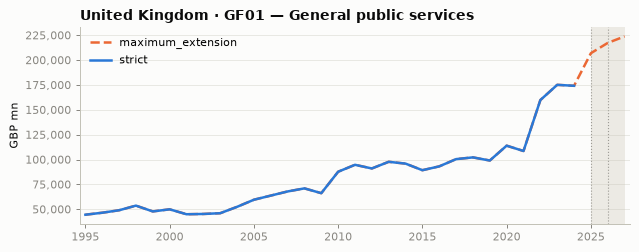

recipe: 1995-2024: anchor outturn (ONS_ESA_T11, grade A)  ·  2025: forward stitch (EC_AMECO, grade D)  ·
        2026-2027: proxy forecast (EC_AMECO, grade D)
ends:   [no_official_forecast] §7.9: GF01 total has no direct forecast source; strict ends at the last
        actual — maximum_extension carries the mandated GF01_7-growth proxy (grade D, coverage measured,
        residual_method recorded; D-S4-002)


In [2]:
chart("GBR", "GF01")

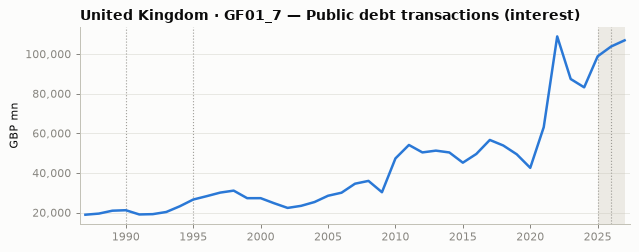

recipe: 1987-1989: backward stitch (EC_AMECO, grade B)  ·  1990-1994: backward stitch (ONS_PSF_INTEREST,
        grade B)  ·  1995-2024: anchor outturn (ONS_ESA_T11, grade A)  ·  2025: forward stitch (EC_AMECO,
        grade B)  ·  2026-2027: official forecast (EC_AMECO, grade B)
ends:   source horizon: EC_AMECO ends 2027 (V10)


In [3]:
chart("GBR", "GF01_7")

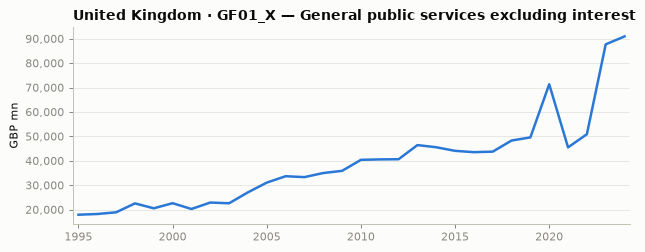

recipe: 1995-2024: derived by identity (ONS_ESA_T11, grade A)
ends:   [no_official_forecast] never forecast by construction (D10); derived only


In [4]:
chart("GBR", "GF01_X")

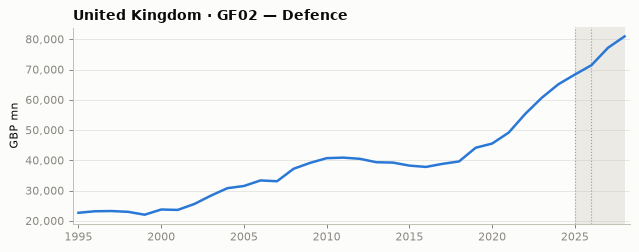

recipe: 1995-2024: anchor outturn (ONS_ESA_T11, grade A)  ·  2025: forward stitch (HMT_PESA, grade B)  ·
        2026-2028: official forecast (HMT_PESA, grade B)
ends:   source horizon: HMT_PESA ends 2028 (V10)


In [5]:
chart("GBR", "GF02")

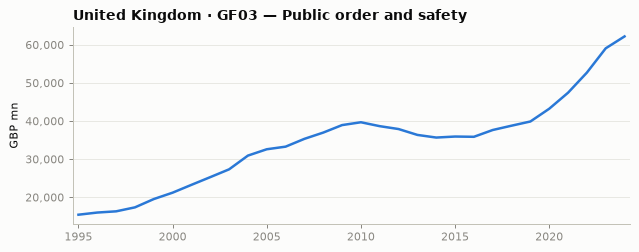

recipe: 1995-2024: anchor outturn (ONS_ESA_T11, grade A)
ends:   [no_official_forecast] D7: no official forecast identified anywhere (seed register and Stage 3
        search: AMECO GG aggregates, AR 2024, DSM 2025, Steuerschätzung); strict and maximum end at the last
        actual


In [6]:
chart("GBR", "GF03")

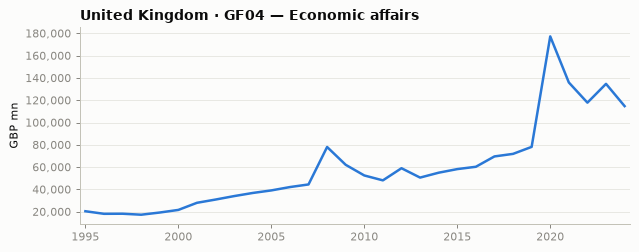

recipe: 1995-2024: anchor outturn (ONS_ESA_T11, grade A)
ends:   [no_official_forecast] D7: no official forecast identified anywhere (seed register and Stage 3
        search: AMECO GG aggregates, AR 2024, DSM 2025, Steuerschätzung); strict and maximum end at the last
        actual


In [7]:
chart("GBR", "GF04")

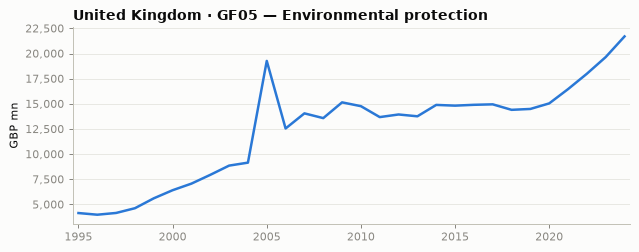

recipe: 1995-2024: anchor outturn (ONS_ESA_T11, grade A)
ends:   [no_official_forecast] D7: no official forecast identified anywhere (seed register and Stage 3
        search: AMECO GG aggregates, AR 2024, DSM 2025, Steuerschätzung); strict and maximum end at the last
        actual


In [8]:
chart("GBR", "GF05")

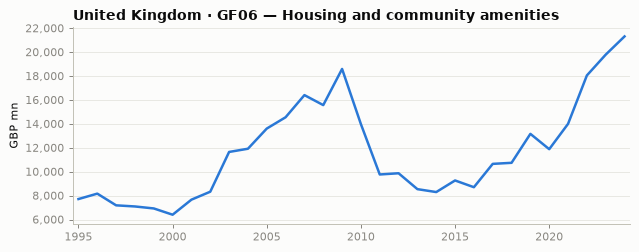

recipe: 1995-2024: anchor outturn (ONS_ESA_T11, grade A)
ends:   [no_official_forecast] D7: no official forecast identified anywhere (seed register and Stage 3
        search: AMECO GG aggregates, AR 2024, DSM 2025, Steuerschätzung); strict and maximum end at the last
        actual


In [9]:
chart("GBR", "GF06")

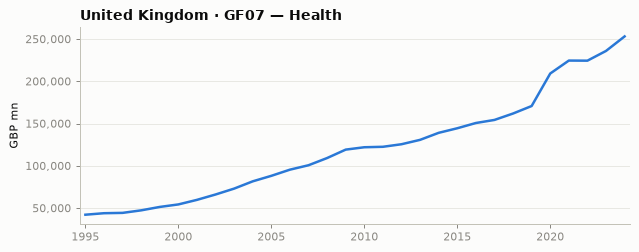

recipe: 1995-2024: anchor outturn (ONS_ESA_T11, grade A)
ends:   [source_blocked] FRS July 2025 (hand-retrieved, D-S7-001) is thematic — pensions, balance sheet,
        climate — and carries no long-term health projection; the FRS edition with functional long-term
        projections (2024, or 2026 if published) is not in hand and obr.uk remains challenge-blocked (OQ-6);
        strict ends at the last actual


In [10]:
chart("GBR", "GF07")

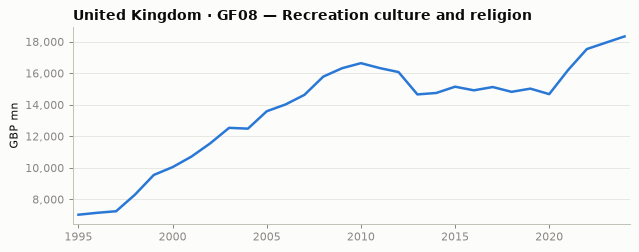

recipe: 1995-2024: anchor outturn (ONS_ESA_T11, grade A)
ends:   [no_official_forecast] D7: no official forecast identified anywhere (seed register and Stage 3
        search: AMECO GG aggregates, AR 2024, DSM 2025, Steuerschätzung); strict and maximum end at the last
        actual


In [11]:
chart("GBR", "GF08")

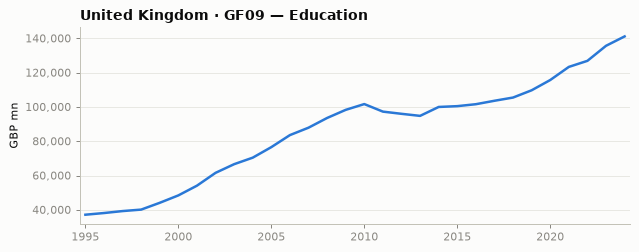

recipe: 1995-2024: anchor outturn (ONS_ESA_T11, grade A)
ends:   [source_blocked] as GF07: no education long-term projection in the FRS July 2025 edition in hand
        (OQ-6); strict ends at the last actual


In [12]:
chart("GBR", "GF09")

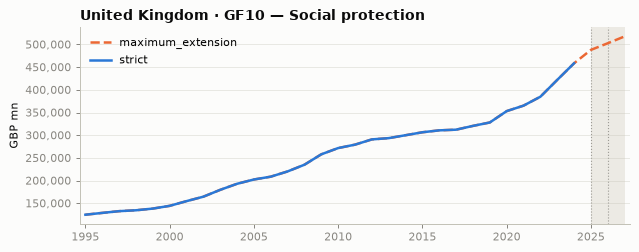

recipe: 1995-2024: anchor outturn (ONS_ESA_T11, grade A)  ·  2025: forward stitch (EC_AMECO, grade C)  ·
        2026-2027: proxy forecast (EC_AMECO, grade C)
ends:   [grade_below_strict] maximum_extension carries the AMECO D.62 dominant-component proxy to 2027
        (grade C, §7.8); the EFO welfare-spending series was measured as a longer C-band candidate but its
        table starts at FY 2024-25, leaving no year in common with the GG anchor to measure §9.2 coverage on
        — recorded, not applied (D-S7-003)


In [13]:
chart("GBR", "GF10")

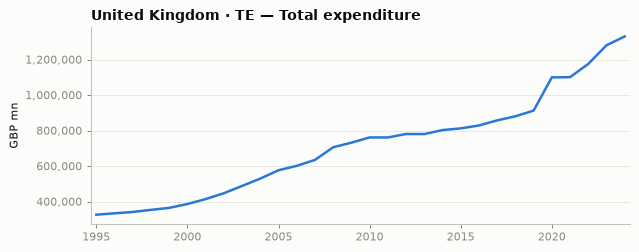

recipe: 1995-2024: anchor outturn (ONS_ESA_T11, grade A)


In [14]:
chart("GBR", "TE")

## 1.2 Revenue — ESA

Ten revenue types from VAT through to other transfers receivable, and total revenue.

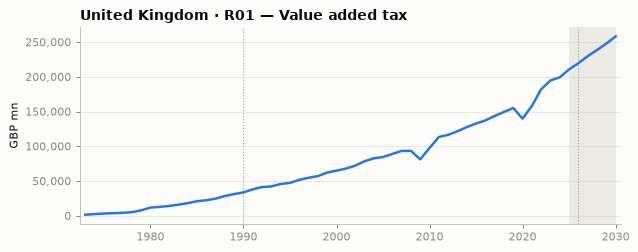

recipe: 1973-1989: backward stitch (OECD_RS, grade B)  ·  1990-2025: anchor outturn (ONS_GG_RECEIPTS, grade
        A)  ·  2026-2030: composite forecast (OBR_EFO_LATEST, grade B)
ends:   source horizon: OBR_EFO_LATEST ends 2030 (V10)


In [15]:
chart("GBR", "R01")

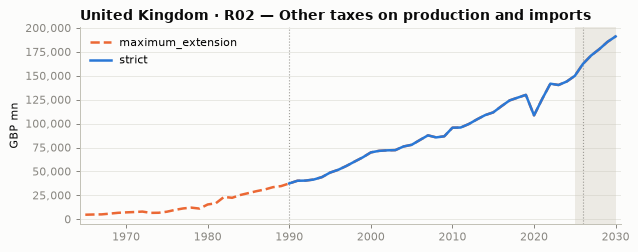

recipe: 1965-1989: backward stitch (OECD_RS, grade C)  ·  1990-2025: derived by identity (ONS_GG_RECEIPTS,
        grade A)  ·  2026-2030: composite forecast (OBR_EFO_LATEST, grade B)
ends:   source horizon: OBR_EFO_LATEST ends 2030 (V10)


In [16]:
chart("GBR", "R02")

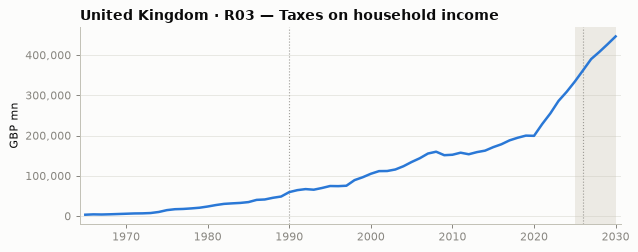

recipe: 1965-1989: backward stitch (OECD_RS, grade B)  ·  1990-2025: anchor outturn (ONS_GG_RECEIPTS, grade
        A)  ·  2026-2030: composite forecast (OBR_EFO_LATEST, grade B)
ends:   source horizon: OBR_EFO_LATEST ends 2030 (V10)


In [17]:
chart("GBR", "R03")

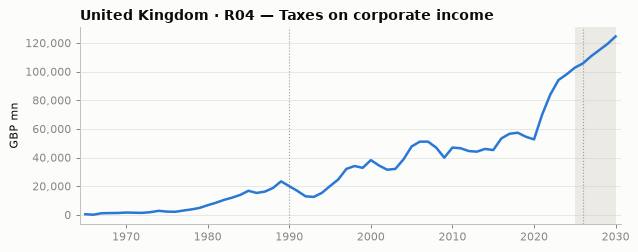

recipe: 1965-1989: backward stitch (OECD_RS, grade B)  ·  1990-2025: anchor outturn (ONS_GG_RECEIPTS, grade
        A)  ·  2026-2030: composite forecast (OBR_EFO_LATEST, grade B)
ends:   source horizon: OBR_EFO_LATEST ends 2030 (V10)


In [18]:
chart("GBR", "R04")

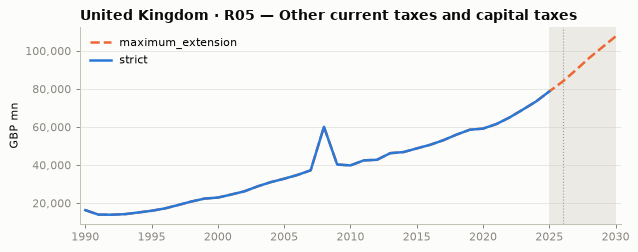

recipe: 1990-2025: derived by identity (ONS_GG_RECEIPTS, grade A)  ·  2026-2030: composite forecast
        (OBR_EFO_LATEST, grade C)
ends:   [grade_below_strict] OBR council tax + inheritance tax + licence fee composite measured at 79% of
        the line (C) — applied in maximum_extension to 2030; the remaining D.59/D.91 items have no forecast
        anywhere (D7 lists R05 as partial); AMECO UTKG (11%, D) recorded, not applied


In [19]:
chart("GBR", "R05")

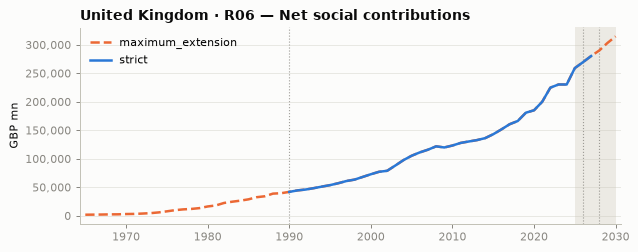

recipe: 1965-1989: backward stitch (OECD_RS, grade C)  ·  1990-2025: anchor outturn (ONS_GG_RECEIPTS, grade
        A)  ·  2026-2027: official forecast (EC_AMECO, grade A)  ·  2028-2030: official forecast
        (OBR_EFO_LATEST, grade C)
ends:   source horizon: OBR_EFO_LATEST ends 2030 (V10)


In [20]:
chart("GBR", "R06")

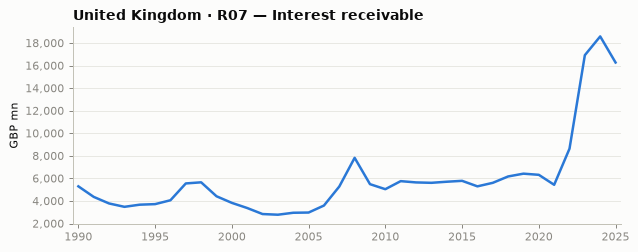

recipe: 1990-2025: anchor outturn (ONS_GG_RECEIPTS, grade A)
ends:   [no_machine_readable_source] no usable GG interest-receivable forecast: AMECO has no D.41 resources
        series (UYVG is subsidies); DSM publishes payable interest only; the OBR 'PS interest and dividend
        receipts' candidate (D-S7-003) mixes dividends and the PS perimeter into the line and measures
        outside every band — recorded, not applied; NI/PB forecast ledger therefore stays empty (§4.3)


In [21]:
chart("GBR", "R07")

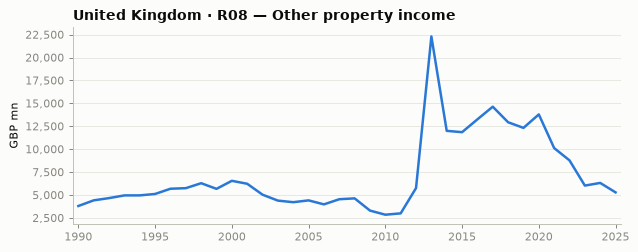

recipe: 1990-2025: derived by identity (ONS_GG_RECEIPTS, grade A)
ends:   [no_official_forecast] D7: no official forecast identified anywhere (seed register and Stage 3
        search: AMECO GG aggregates, AR 2024, DSM 2025, Steuerschätzung); strict and maximum end at the last
        actual


In [22]:
chart("GBR", "R08")

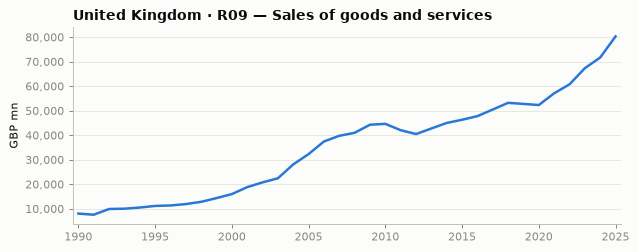

recipe: 1990-2025: derived by identity (ONS_GG_RECEIPTS, grade A)
ends:   [no_machine_readable_source] AMECO publishes no UK UTOG/UROG history (OQ-4 pattern) and the EFO
        receipts tables do not separate P.11+P.12+P.131 sales (GOS and 'other receipts' are different
        concepts) — no measurable composite


In [23]:
chart("GBR", "R09")

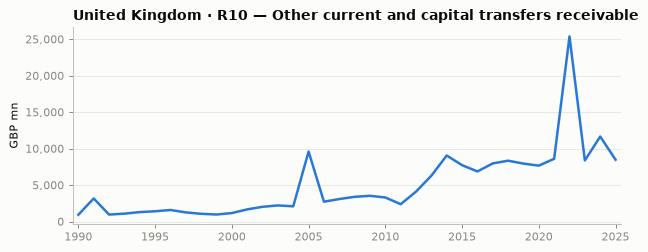

recipe: 1990-2025: derived by identity (ONS_GG_RECEIPTS, grade A)
ends:   [no_official_forecast] D7: no official forecast identified anywhere (seed register and Stage 3
        search: AMECO GG aggregates, AR 2024, DSM 2025, Steuerschätzung); strict and maximum end at the last
        actual


In [24]:
chart("GBR", "R10")

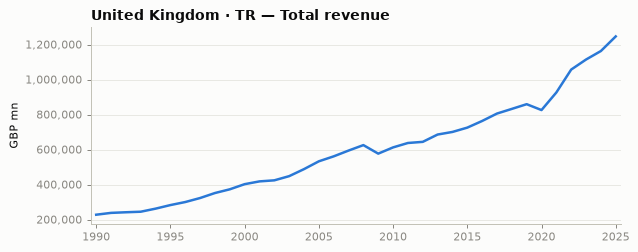

recipe: 1990-2025: anchor outturn (ONS_GG_RECEIPTS, grade A)


In [25]:
chart("GBR", "TR")

## 1.3 Balance ledger

Outturn years only, single line each — the two variants are identical here. TR and TE are the balance anchor's own totals, not sums of the lines above.

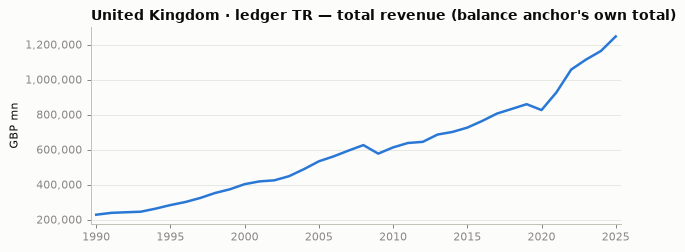

outturn years 1990-2025; source ONS_GG_RECEIPTS


In [26]:
ledger_chart("GBR", "TR")

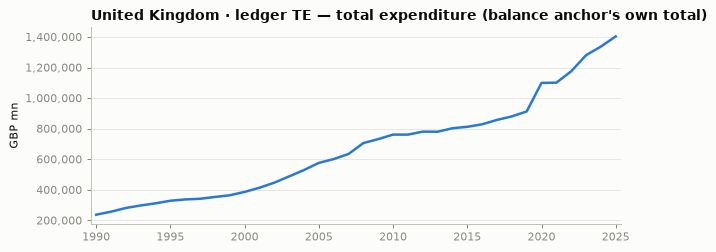

outturn years 1990-2025; source ONS_GG_RECEIPTS


In [27]:
ledger_chart("GBR", "TE")

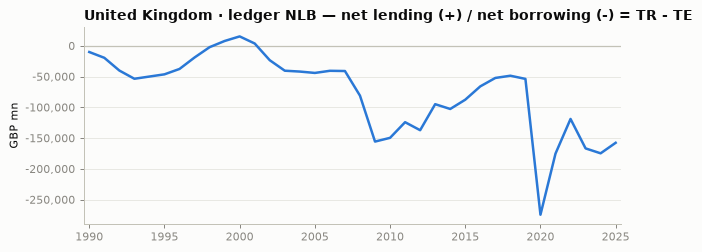

outturn years 1990-2025; source ONS_GG_RECEIPTS


In [28]:
ledger_chart("GBR", "NLB")

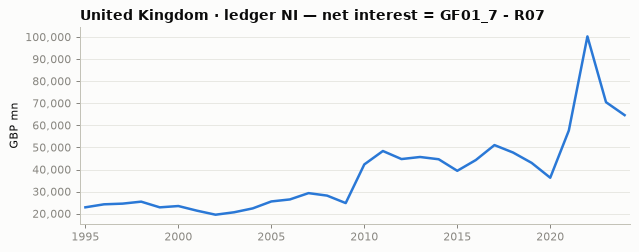

outturn years 1990-2025; source ONS_GG_RECEIPTS; no value for [1990, 1991, 1992, 1993, 1994, 2025]


In [29]:
ledger_chart("GBR", "NI")

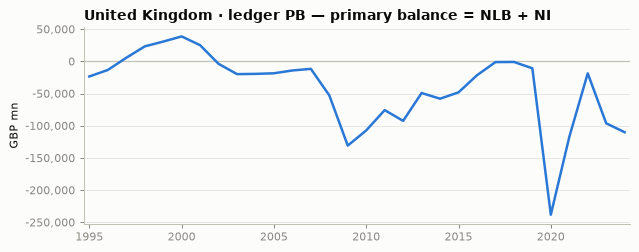

outturn years 1990-2025; source ONS_GG_RECEIPTS; no value for [1990, 1991, 1992, 1993, 1994, 2025]


In [30]:
ledger_chart("GBR", "PB")

---

# 2. France (FRA)

## 2.1 Expenditure — COFOG

Ten Level I functions, the Level II interest line `GF01_7`, the identity `GF01_X = GF01 − GF01_7`, and total expenditure.

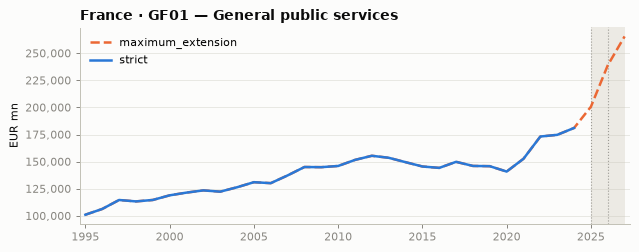

recipe: 1995-2024: anchor outturn (EUROSTAT_GOV10A_EXP, grade A)  ·  2025: forward stitch (EC_AMECO, grade
        D)  ·  2026-2027: proxy forecast (EC_AMECO, grade D)
ends:   [no_official_forecast] §7.9: GF01 total has no direct forecast source; strict ends at the last
        actual — maximum_extension carries the mandated GF01_7-growth proxy (grade D, coverage measured,
        residual_method recorded; D-S4-002)


In [31]:
chart("FRA", "GF01")

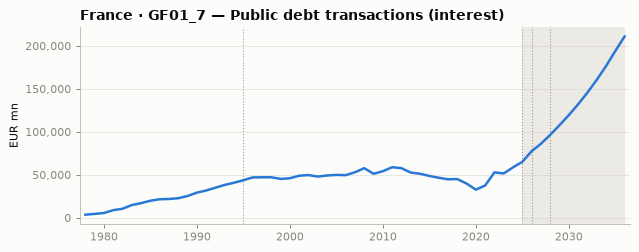

recipe: 1978-1994: backward stitch (EC_AMECO, grade B)  ·  1995-2024: anchor outturn (EUROSTAT_GOV10A_EXP,
        grade A)  ·  2025: forward stitch (EC_AMECO, grade B)  ·  2026-2027: official forecast (EC_AMECO,
        grade B)  ·  2028-2036: official forecast (EC_DSM, grade B)
ends:   source horizon: EC_DSM ends 2036 (V10)


In [32]:
chart("FRA", "GF01_7")

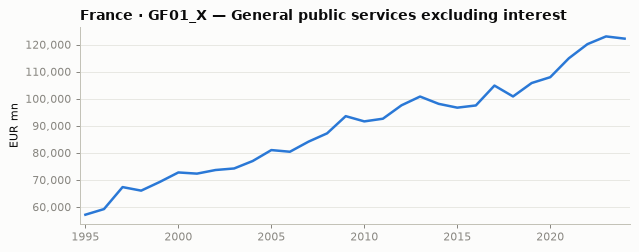

recipe: 1995-2024: derived by identity (EUROSTAT_GOV10A_EXP, grade A)
ends:   [no_official_forecast] never forecast by construction (D10); derived only


In [33]:
chart("FRA", "GF01_X")

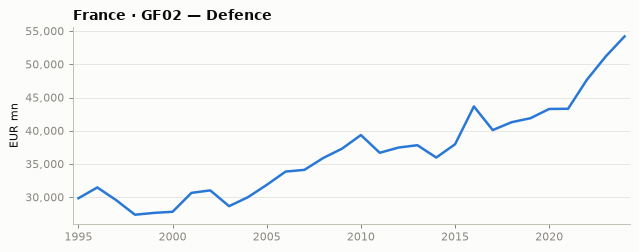

recipe: 1995-2024: anchor outturn (EUROSTAT_GOV10A_EXP, grade A)
ends:   [source_blocked] identified source FRA_LPM_2030 (military programming law) is PDF-only; §11.4 manual
        ingestion requires an independent second keying unavailable to a single-agent session (OQ-5
        precedent) — OQ-6; strict ends at the last actual


In [34]:
chart("FRA", "GF02")

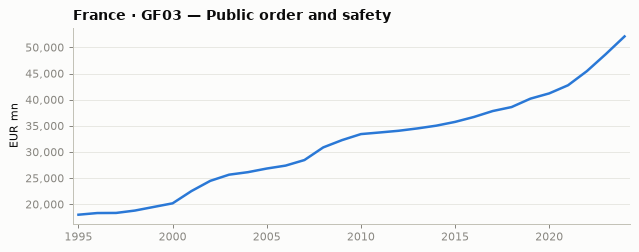

recipe: 1995-2024: anchor outturn (EUROSTAT_GOV10A_EXP, grade A)
ends:   [no_official_forecast] D7: no official forecast identified anywhere (seed register and Stage 3
        search: AMECO GG aggregates, AR 2024, DSM 2025, Steuerschätzung); strict and maximum end at the last
        actual


In [35]:
chart("FRA", "GF03")

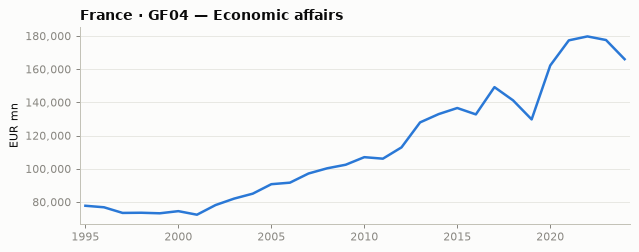

recipe: 1995-2024: anchor outturn (EUROSTAT_GOV10A_EXP, grade A)
ends:   [no_official_forecast] D7: no official forecast identified anywhere (seed register and Stage 3
        search: AMECO GG aggregates, AR 2024, DSM 2025, Steuerschätzung); strict and maximum end at the last
        actual


In [36]:
chart("FRA", "GF04")

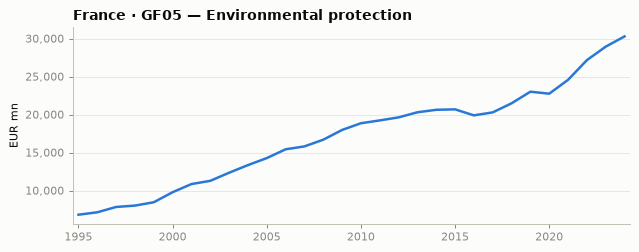

recipe: 1995-2024: anchor outturn (EUROSTAT_GOV10A_EXP, grade A)
ends:   [no_official_forecast] D7: no official forecast identified anywhere (seed register and Stage 3
        search: AMECO GG aggregates, AR 2024, DSM 2025, Steuerschätzung); strict and maximum end at the last
        actual


In [37]:
chart("FRA", "GF05")

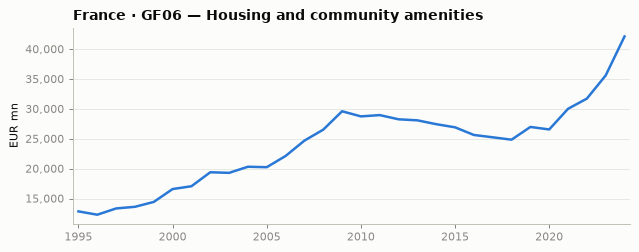

recipe: 1995-2024: anchor outturn (EUROSTAT_GOV10A_EXP, grade A)
ends:   [no_official_forecast] D7: no official forecast identified anywhere (seed register and Stage 3
        search: AMECO GG aggregates, AR 2024, DSM 2025, Steuerschätzung); strict and maximum end at the last
        actual


In [38]:
chart("FRA", "GF06")

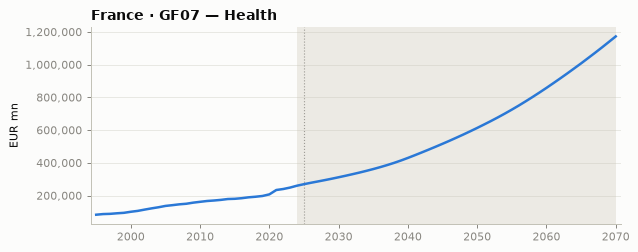

recipe: 1995-2024: anchor outturn (EUROSTAT_GOV10A_EXP, grade A)  ·  2025-2070: official forecast
        (EC_AGEING_2024, grade B)
ends:   source horizon: EC_AGEING_2024 ends 2070 (V10)


In [39]:
chart("FRA", "GF07")

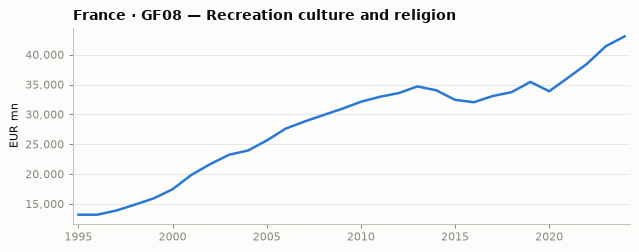

recipe: 1995-2024: anchor outturn (EUROSTAT_GOV10A_EXP, grade A)
ends:   [no_official_forecast] D7: no official forecast identified anywhere (seed register and Stage 3
        search: AMECO GG aggregates, AR 2024, DSM 2025, Steuerschätzung); strict and maximum end at the last
        actual


In [40]:
chart("FRA", "GF08")

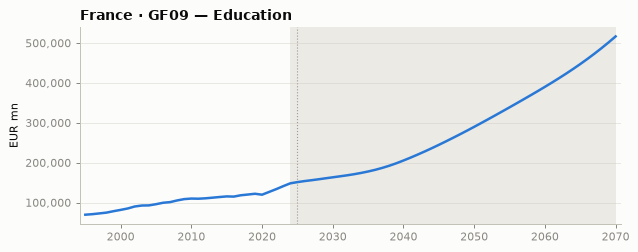

recipe: 1995-2024: anchor outturn (EUROSTAT_GOV10A_EXP, grade A)  ·  2025-2070: official forecast
        (EC_AGEING_2024, grade B)
ends:   source horizon: EC_AGEING_2024 ends 2070 (V10)


In [41]:
chart("FRA", "GF09")

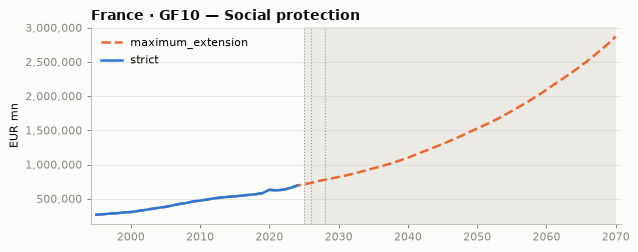

recipe: 1995-2024: anchor outturn (EUROSTAT_GOV10A_EXP, grade A)  ·  2025: forward stitch (EC_AMECO, grade
        C)  ·  2026-2027: proxy forecast (EC_AMECO, grade C)  ·  2028-2070: composite forecast
        (EC_AGEING_2024, grade C)
ends:   [grade_below_strict] AR pensions+LTC composite measured at 69% of GF10 (grade C: no official
        projection of family/housing/unemployment components) — no strict forecast; maximum_extension chains
        the AMECO D.62 proxy (to 2027) into the AR composite (to 2070) per D12, overlap divergence under the
        V16 threshold


In [42]:
chart("FRA", "GF10")

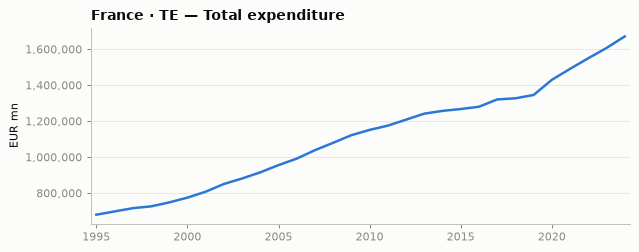

recipe: 1995-2024: anchor outturn (EUROSTAT_GOV10A_EXP, grade A)


In [43]:
chart("FRA", "TE")

## 2.2 Revenue — ESA

Ten revenue types from VAT through to other transfers receivable, and total revenue.

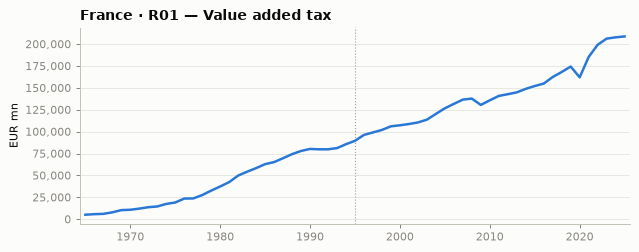

recipe: 1965-1994: backward stitch (OECD_RS, grade B)  ·  1995-2025: anchor outturn (EUROSTAT_GOV10A_MAIN,
        grade A)
ends:   [source_blocked] identified source FRA_LPFP_PSTAB (prélèvements obligatoires) is PDF-only; §11.4
        manual ingestion requires an independent second keying unavailable to a single-agent session (OQ-5
        precedent) — OQ-6; strict ends at the last actual


In [44]:
chart("FRA", "R01")

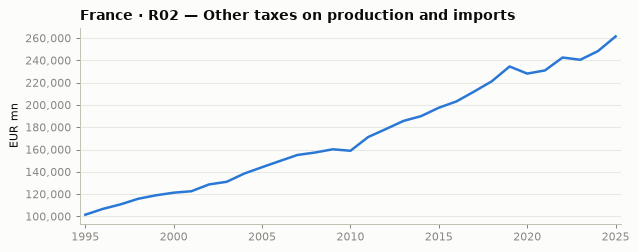

recipe: 1995-2025: derived by identity (EUROSTAT_GOV10A_MAIN, grade A)
ends:   [source_blocked] identified source FRA_LPFP_PSTAB is PDF-only; §11.4 manual ingestion requires an
        independent second keying unavailable to a single-agent session (OQ-5 precedent) — OQ-6; strict ends
        at the last actual


In [45]:
chart("FRA", "R02")

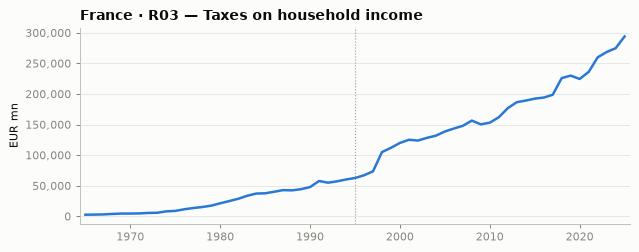

recipe: 1965-1994: backward stitch (OECD_RS, grade B)  ·  1995-2025: anchor outturn (EUROSTAT_GOV10A_MAIN,
        grade A)
ends:   [source_blocked] identified source FRA_LPFP_PSTAB is PDF-only; §11.4 manual ingestion requires an
        independent second keying unavailable to a single-agent session (OQ-5 precedent) — OQ-6; strict ends
        at the last actual


In [46]:
chart("FRA", "R03")

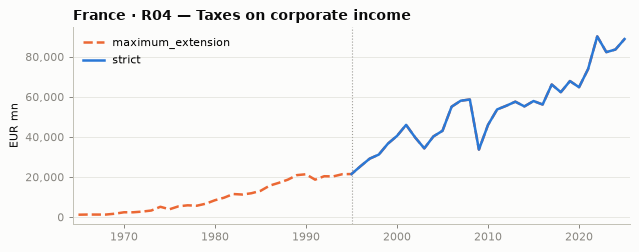

recipe: 1965-1994: backward stitch (OECD_RS, grade C)  ·  1995-2025: anchor outturn (EUROSTAT_GOV10A_MAIN,
        grade A)
ends:   [source_blocked] identified source FRA_LPFP_PSTAB is PDF-only; §11.4 manual ingestion requires an
        independent second keying unavailable to a single-agent session (OQ-5 precedent) — OQ-6; strict ends
        at the last actual


In [47]:
chart("FRA", "R04")

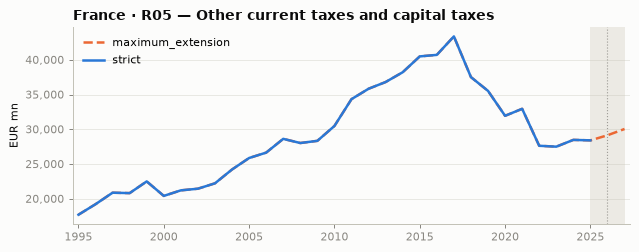

recipe: 1995-2025: derived by identity (EUROSTAT_GOV10A_MAIN, grade A)  ·  2026-2027: proxy forecast
        (EC_AMECO, grade C)
ends:   [grade_below_strict] AMECO UTKG covers 76% of the line (grade C) — no strict forecast; applied in
        maximum_extension as a §7.8 single-component proxy to 2027; D7 lists R05 as partial


In [48]:
chart("FRA", "R05")

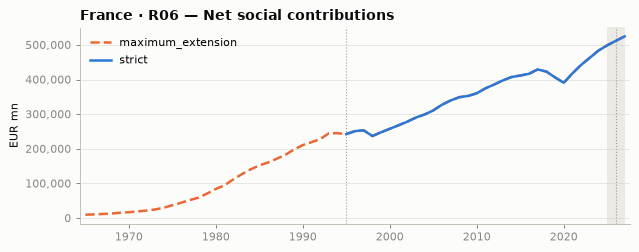

recipe: 1965-1994: backward stitch (OECD_RS, grade C)  ·  1995-2025: anchor outturn (EUROSTAT_GOV10A_MAIN,
        grade A)  ·  2026-2027: official forecast (EC_AMECO, grade A)
ends:   source horizon: EC_AMECO ends 2027 (V10)


In [49]:
chart("FRA", "R06")

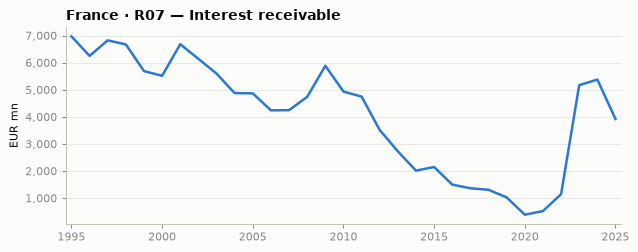

recipe: 1995-2025: anchor outturn (EUROSTAT_GOV10A_MAIN, grade A)
ends:   [no_machine_readable_source] no usable GG interest-receivable forecast: AMECO has no D.41 resources
        series (UYVG is subsidies); DSM publishes payable interest only; the OBR 'PS interest and dividend
        receipts' candidate (D-S7-003) mixes dividends and the PS perimeter into the line and measures
        outside every band — recorded, not applied; NI/PB forecast ledger therefore stays empty (§4.3)


In [50]:
chart("FRA", "R07")

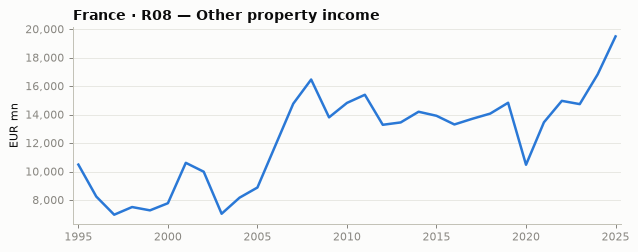

recipe: 1995-2025: derived by identity (EUROSTAT_GOV10A_MAIN, grade A)
ends:   [no_official_forecast] D7: no official forecast identified anywhere (seed register and Stage 3
        search: AMECO GG aggregates, AR 2024, DSM 2025, Steuerschätzung); strict and maximum end at the last
        actual


In [51]:
chart("FRA", "R08")

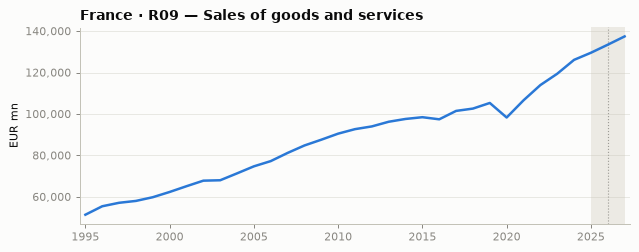

recipe: 1995-2025: anchor outturn (EUROSTAT_GOV10A_MAIN, grade A)  ·  2026-2027: composite forecast
        (EC_AMECO, grade B)
ends:   source horizon: EC_AMECO ends 2027 (V10)


In [52]:
chart("FRA", "R09")

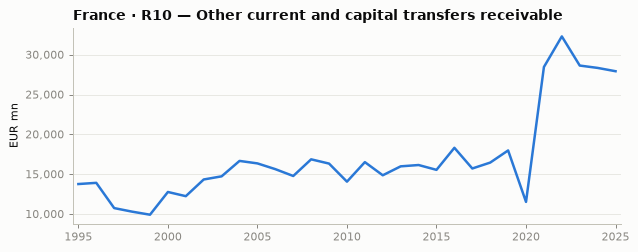

recipe: 1995-2025: derived by identity (EUROSTAT_GOV10A_MAIN, grade A)
ends:   [no_official_forecast] D7: no official forecast identified anywhere (seed register and Stage 3
        search: AMECO GG aggregates, AR 2024, DSM 2025, Steuerschätzung); strict and maximum end at the last
        actual


In [53]:
chart("FRA", "R10")

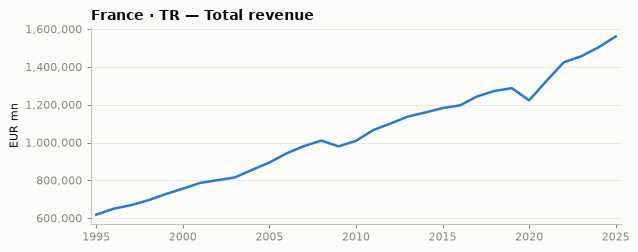

recipe: 1995-2025: anchor outturn (EUROSTAT_GOV10A_MAIN, grade A)


In [54]:
chart("FRA", "TR")

## 2.3 Balance ledger

Outturn years only, single line each — the two variants are identical here. TR and TE are the balance anchor's own totals, not sums of the lines above.

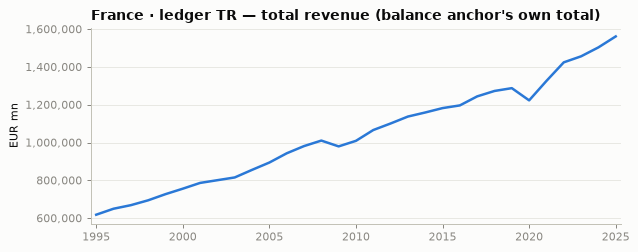

outturn years 1995-2025; source EUROSTAT_GOV10A_MAIN


In [55]:
ledger_chart("FRA", "TR")

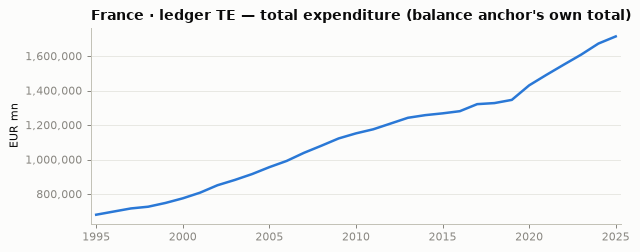

outturn years 1995-2025; source EUROSTAT_GOV10A_MAIN


In [56]:
ledger_chart("FRA", "TE")

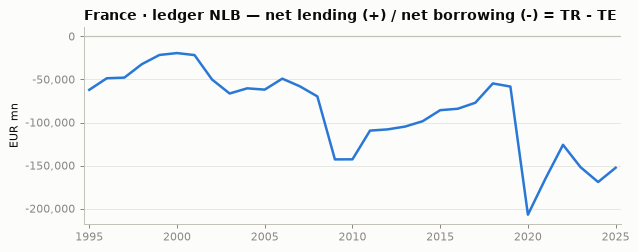

outturn years 1995-2025; source EUROSTAT_GOV10A_MAIN


In [57]:
ledger_chart("FRA", "NLB")

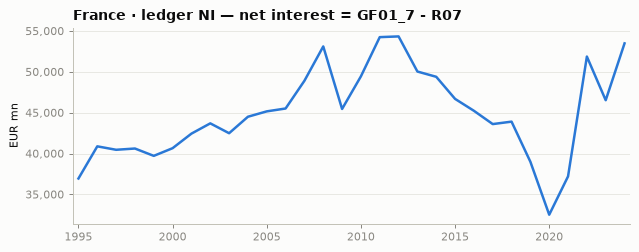

outturn years 1995-2025; source EUROSTAT_GOV10A_MAIN; no value for [2025]


In [58]:
ledger_chart("FRA", "NI")

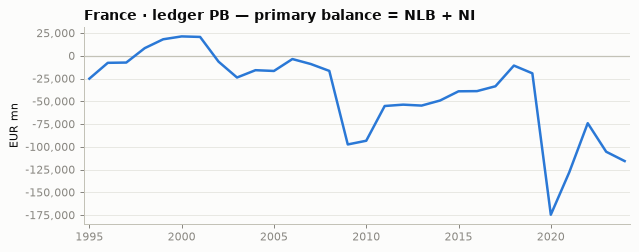

outturn years 1995-2025; source EUROSTAT_GOV10A_MAIN; no value for [2025]


In [59]:
ledger_chart("FRA", "PB")

---

# 3. Germany (DEU)

## 3.1 Expenditure — COFOG

Ten Level I functions, the Level II interest line `GF01_7`, the identity `GF01_X = GF01 − GF01_7`, and total expenditure.

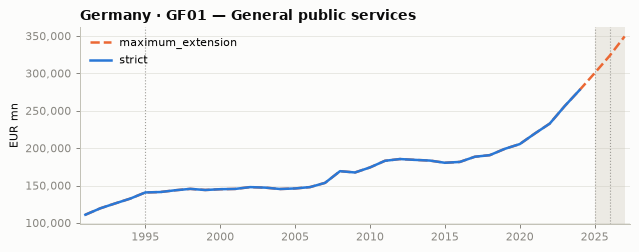

recipe: 1991-1994: backward stitch (IMF_GFS, grade B)  ·  1995-2024: anchor outturn (EUROSTAT_GOV10A_EXP,
        grade A)  ·  2025: forward stitch (EC_AMECO, grade D)  ·  2026-2027: proxy forecast (EC_AMECO, grade
        D)
ends:   [no_official_forecast] §7.9: GF01 total has no direct forecast source; strict ends at the last
        actual — maximum_extension carries the mandated GF01_7-growth proxy (grade D, coverage measured,
        residual_method recorded; D-S4-002)


In [60]:
chart("DEU", "GF01")

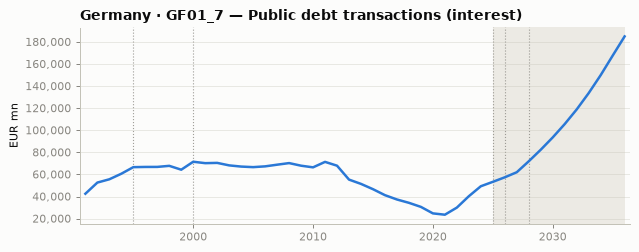

recipe: 1991-1994: backward stitch (EC_AMECO, grade B)  ·  1995-1999: anchor outturn on the D10 fallback
        concept (EUROSTAT_GOV10A_EXP, grade B)  ·  2000-2024: anchor outturn (EUROSTAT_GOV10A_EXP, grade A)
        ·  2025: forward stitch (EC_AMECO, grade B)  ·  2026-2027: official forecast (EC_AMECO, grade B)  ·
        2028-2036: official forecast (EC_DSM, grade B)
ends:   source horizon: EC_DSM ends 2036 (V10)


In [61]:
chart("DEU", "GF01_7")

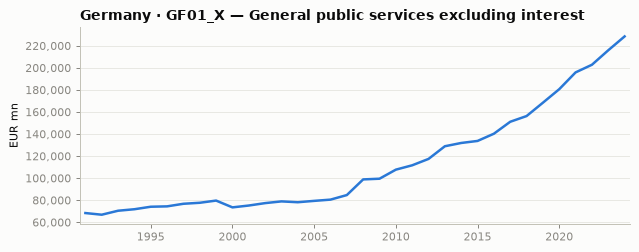

recipe: 1991-1999: derived by identity (EUROSTAT_GOV10A_EXP, grade B)  ·  2000-2024: derived by identity
        (EUROSTAT_GOV10A_EXP, grade A)
ends:   [no_official_forecast] never forecast by construction (D10); derived only


In [62]:
chart("DEU", "GF01_X")

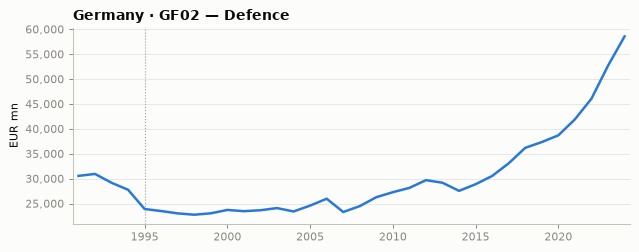

recipe: 1991-1994: backward stitch (IMF_GFS, grade B)  ·  1995-2024: anchor outturn (EUROSTAT_GOV10A_EXP,
        grade A)
ends:   [source_blocked] identified source DEU_BMF_FINPLAN (Epl. 14 + Sondervermögen Bundeswehr) is PDF-
        only; §11.4 manual ingestion requires an independent second keying unavailable to a single-agent
        session (OQ-5 precedent) — OQ-6; strict ends at the last actual


In [63]:
chart("DEU", "GF02")

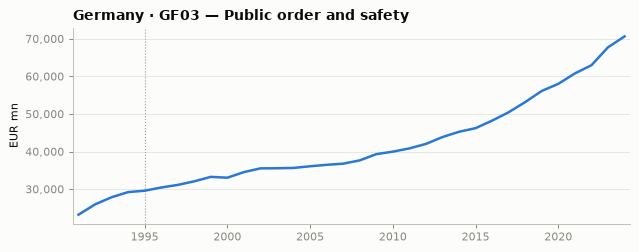

recipe: 1991-1994: backward stitch (IMF_GFS, grade B)  ·  1995-2024: anchor outturn (EUROSTAT_GOV10A_EXP,
        grade A)
ends:   [no_official_forecast] D7: no official forecast identified anywhere (seed register and Stage 3
        search: AMECO GG aggregates, AR 2024, DSM 2025, Steuerschätzung); strict and maximum end at the last
        actual


In [64]:
chart("DEU", "GF03")

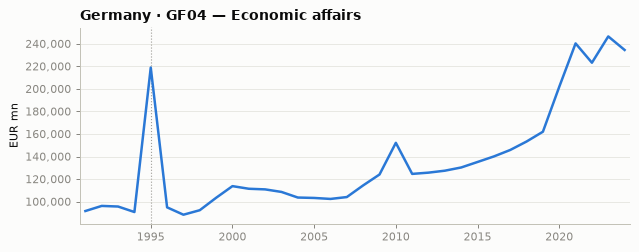

recipe: 1991-1994: backward stitch (IMF_GFS, grade B)  ·  1995-2024: anchor outturn (EUROSTAT_GOV10A_EXP,
        grade A)
ends:   [no_official_forecast] D7: no official forecast identified anywhere (seed register and Stage 3
        search: AMECO GG aggregates, AR 2024, DSM 2025, Steuerschätzung); strict and maximum end at the last
        actual


In [65]:
chart("DEU", "GF04")

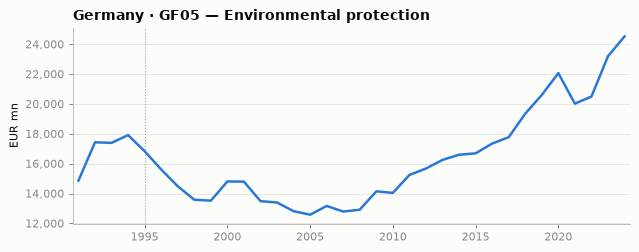

recipe: 1991-1994: backward stitch (IMF_GFS, grade B)  ·  1995-2024: anchor outturn (EUROSTAT_GOV10A_EXP,
        grade A)
ends:   [no_official_forecast] D7: no official forecast identified anywhere (seed register and Stage 3
        search: AMECO GG aggregates, AR 2024, DSM 2025, Steuerschätzung); strict and maximum end at the last
        actual


In [66]:
chart("DEU", "GF05")

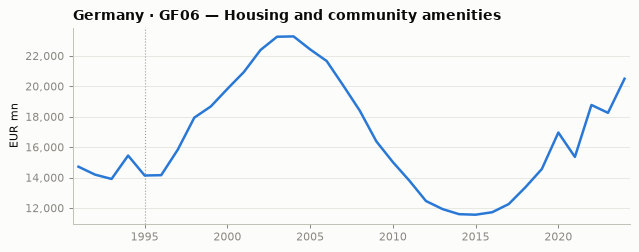

recipe: 1991-1994: backward stitch (IMF_GFS, grade B)  ·  1995-2024: anchor outturn (EUROSTAT_GOV10A_EXP,
        grade A)
ends:   [no_official_forecast] D7: no official forecast identified anywhere (seed register and Stage 3
        search: AMECO GG aggregates, AR 2024, DSM 2025, Steuerschätzung); strict and maximum end at the last
        actual


In [67]:
chart("DEU", "GF06")

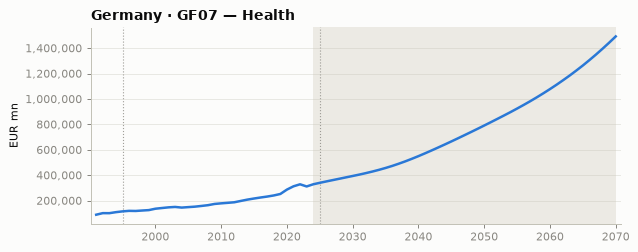

recipe: 1991-1994: backward stitch (IMF_GFS, grade B)  ·  1995-2024: anchor outturn (EUROSTAT_GOV10A_EXP,
        grade A)  ·  2025-2070: official forecast (EC_AGEING_2024, grade B)
ends:   source horizon: EC_AGEING_2024 ends 2070 (V10)


In [68]:
chart("DEU", "GF07")

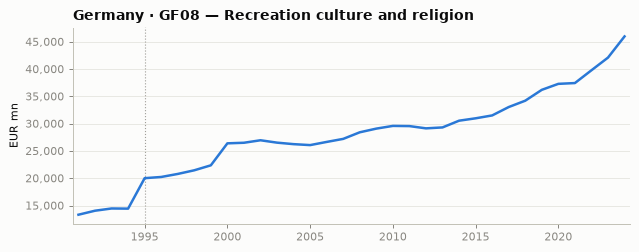

recipe: 1991-1994: backward stitch (IMF_GFS, grade B)  ·  1995-2024: anchor outturn (EUROSTAT_GOV10A_EXP,
        grade A)
ends:   [no_official_forecast] D7: no official forecast identified anywhere (seed register and Stage 3
        search: AMECO GG aggregates, AR 2024, DSM 2025, Steuerschätzung); strict and maximum end at the last
        actual


In [69]:
chart("DEU", "GF08")

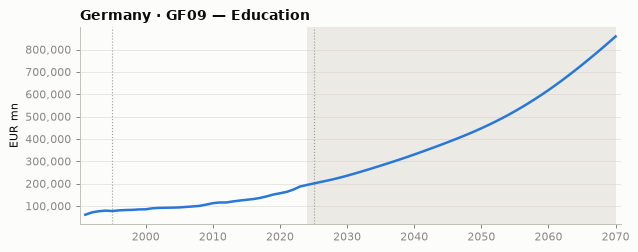

recipe: 1991-1994: backward stitch (IMF_GFS, grade B)  ·  1995-2024: anchor outturn (EUROSTAT_GOV10A_EXP,
        grade A)  ·  2025-2070: official forecast (EC_AGEING_2024, grade B)
ends:   source horizon: EC_AGEING_2024 ends 2070 (V10)


In [70]:
chart("DEU", "GF09")

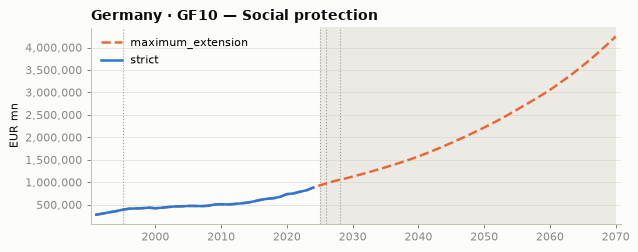

recipe: 1991-1994: backward stitch (IMF_GFS, grade B)  ·  1995-2024: anchor outturn (EUROSTAT_GOV10A_EXP,
        grade A)  ·  2025: forward stitch (EC_AMECO, grade C)  ·  2026-2027: proxy forecast (EC_AMECO, grade
        C)  ·  2028-2070: composite forecast (EC_AGEING_2024, grade C)
ends:   [grade_below_strict] AR pensions+LTC composite measured at 61% of GF10 (grade C); BMAS
        Rentenversicherungsbericht blocked (bmas.de egress, OQ-6) — no strict forecast; maximum_extension
        chains the AMECO D.62 proxy (to 2027) into the AR composite (to 2070) per D12


In [71]:
chart("DEU", "GF10")

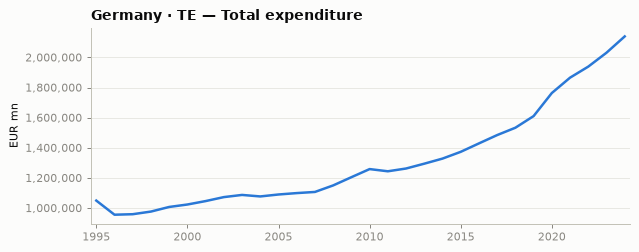

recipe: 1995-2024: anchor outturn (EUROSTAT_GOV10A_EXP, grade A)


In [72]:
chart("DEU", "TE")

## 3.2 Revenue — ESA

Ten revenue types from VAT through to other transfers receivable, and total revenue.

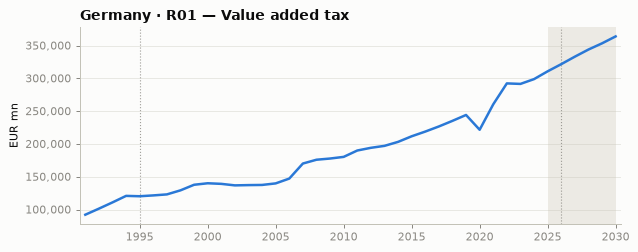

recipe: 1991-1994: backward stitch (OECD_RS, grade B)  ·  1995-2025: anchor outturn (EUROSTAT_GOV10A_MAIN,
        grade A)  ·  2026-2030: official forecast (DEU_STEUERSCHAETZUNG, grade B)
ends:   source horizon: DEU_STEUERSCHAETZUNG ends 2030 (V10)


In [73]:
chart("DEU", "R01")

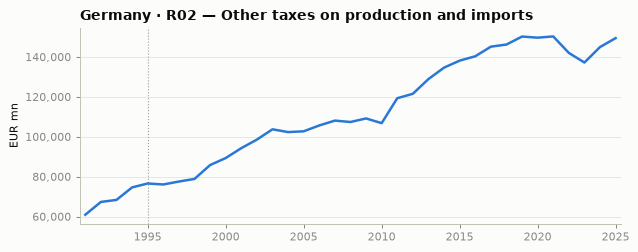

recipe: 1991-1994: backward stitch (OECD_RS, grade B)  ·  1995-2025: derived by identity
        (EUROSTAT_GOV10A_MAIN, grade A)
ends:   [no_machine_readable_source] Steuerschätzung publishes Länder-/Gemeindesteuern only as cash
        aggregates mixing D.2, D.59 and D.91 — no ESA-complete component set for D.2 minus D.211; AMECO UTVG
        is total D.2 only


In [74]:
chart("DEU", "R02")

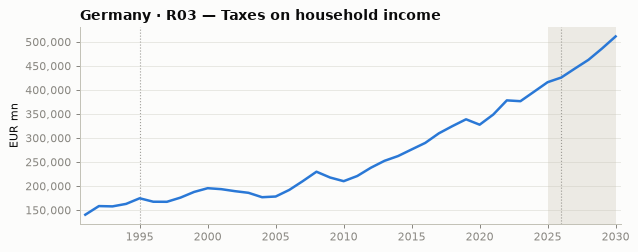

recipe: 1991-1994: backward stitch (OECD_RS, grade B)  ·  1995-2025: anchor outturn (EUROSTAT_GOV10A_MAIN,
        grade A)  ·  2026-2030: composite forecast (DEU_STEUERSCHAETZUNG, grade B)
ends:   source horizon: DEU_STEUERSCHAETZUNG ends 2030 (V10)


In [75]:
chart("DEU", "R03")

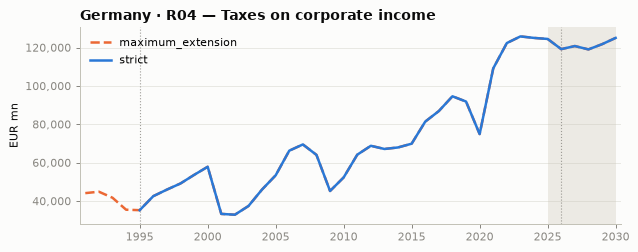

recipe: 1991-1994: backward stitch (OECD_RS, grade C)  ·  1995-2025: anchor outturn (EUROSTAT_GOV10A_MAIN,
        grade A)  ·  2026-2030: composite forecast (DEU_STEUERSCHAETZUNG, grade B)
ends:   source horizon: DEU_STEUERSCHAETZUNG ends 2030 (V10)


In [76]:
chart("DEU", "R04")

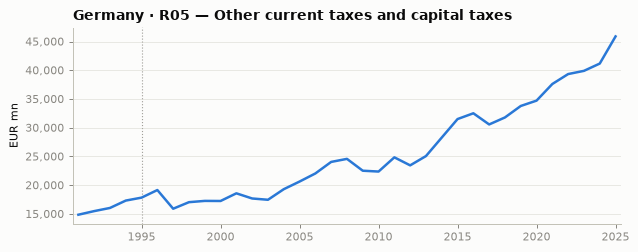

recipe: 1991-1994: backward stitch (OECD_RS, grade B)  ·  1995-2025: derived by identity
        (EUROSTAT_GOV10A_MAIN, grade A)
ends:   [grade_below_strict] AMECO UTKG covers 34% of the line (D, not applied); Erbschaftsteuer is not
        separately published in the Steuerschätzung tables; D7 lists R05 as partial


In [77]:
chart("DEU", "R05")

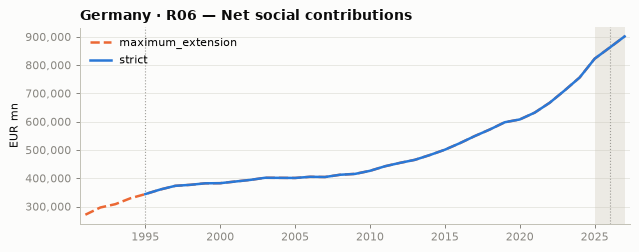

recipe: 1991-1994: backward stitch (OECD_RS, grade C)  ·  1995-2025: anchor outturn (EUROSTAT_GOV10A_MAIN,
        grade A)  ·  2026-2027: official forecast (EC_AMECO, grade A)
ends:   source horizon: EC_AMECO ends 2027 (V10)


In [78]:
chart("DEU", "R06")

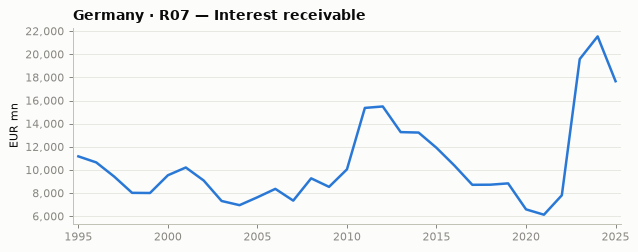

recipe: 1995-2025: anchor outturn (EUROSTAT_GOV10A_MAIN, grade A)
ends:   [no_machine_readable_source] no usable GG interest-receivable forecast: AMECO has no D.41 resources
        series (UYVG is subsidies); DSM publishes payable interest only; the OBR 'PS interest and dividend
        receipts' candidate (D-S7-003) mixes dividends and the PS perimeter into the line and measures
        outside every band — recorded, not applied; NI/PB forecast ledger therefore stays empty (§4.3)


In [79]:
chart("DEU", "R07")

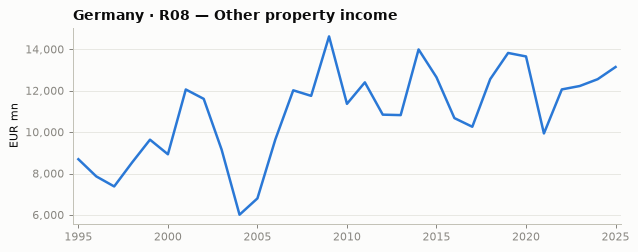

recipe: 1995-2025: derived by identity (EUROSTAT_GOV10A_MAIN, grade A)
ends:   [no_official_forecast] D7: no official forecast identified anywhere (seed register and Stage 3
        search: AMECO GG aggregates, AR 2024, DSM 2025, Steuerschätzung); strict and maximum end at the last
        actual


In [80]:
chart("DEU", "R08")

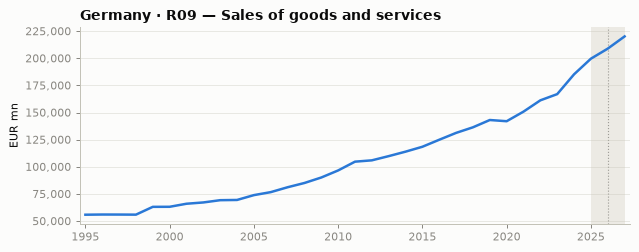

recipe: 1995-2025: anchor outturn (EUROSTAT_GOV10A_MAIN, grade A)  ·  2026-2027: composite forecast
        (EC_AMECO, grade B)
ends:   source horizon: EC_AMECO ends 2027 (V10)


In [81]:
chart("DEU", "R09")

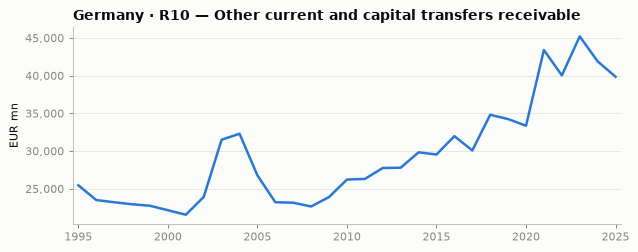

recipe: 1995-2025: derived by identity (EUROSTAT_GOV10A_MAIN, grade A)
ends:   [no_official_forecast] D7: no official forecast identified anywhere (seed register and Stage 3
        search: AMECO GG aggregates, AR 2024, DSM 2025, Steuerschätzung); strict and maximum end at the last
        actual


In [82]:
chart("DEU", "R10")

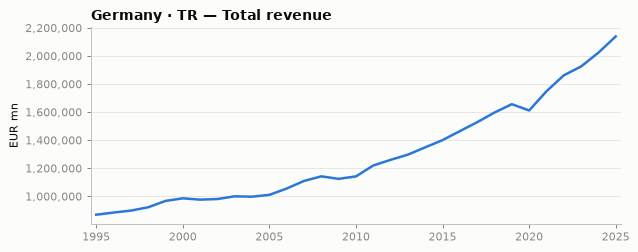

recipe: 1995-2025: anchor outturn (EUROSTAT_GOV10A_MAIN, grade A)


In [83]:
chart("DEU", "TR")

## 3.3 Balance ledger

Outturn years only, single line each — the two variants are identical here. TR and TE are the balance anchor's own totals, not sums of the lines above.

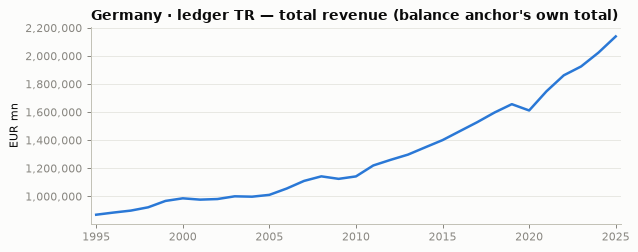

outturn years 1995-2025; source EUROSTAT_GOV10A_MAIN


In [84]:
ledger_chart("DEU", "TR")

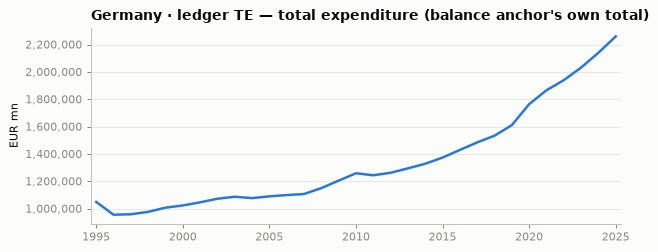

outturn years 1995-2025; source EUROSTAT_GOV10A_MAIN


In [85]:
ledger_chart("DEU", "TE")

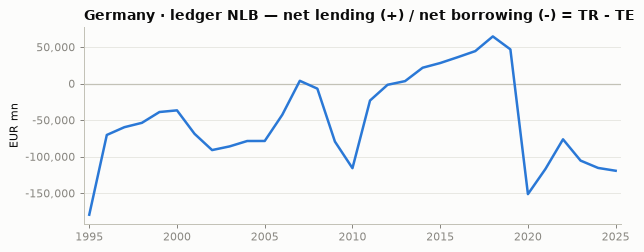

outturn years 1995-2025; source EUROSTAT_GOV10A_MAIN


In [86]:
ledger_chart("DEU", "NLB")

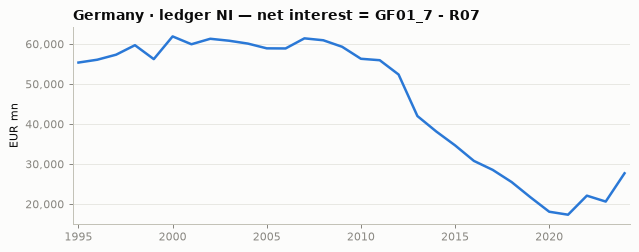

outturn years 1995-2025; source EUROSTAT_GOV10A_MAIN; no value for [2025]


In [87]:
ledger_chart("DEU", "NI")

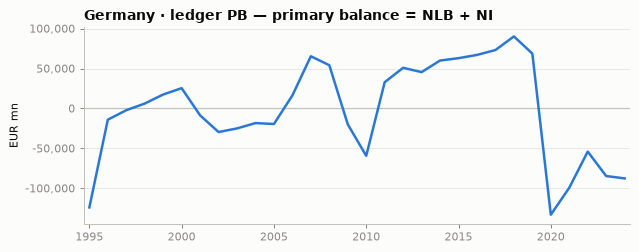

outturn years 1995-2025; source EUROSTAT_GOV10A_MAIN; no value for [2025]


In [88]:
ledger_chart("DEU", "PB")

---

# 4. Reconciliation to the IMF WEO

Do our totals agree with the IMF's? Each chart puts our number and the WEO's on
the same axes over every overlap year, with the gap as a percentage of our total
expenditure underneath.

What to look for: a gap that is **small and flat** is a definitional
difference — a stable perimeter wedge — and is fine. A gap that **drifts or
jumps** is a vintage difference or something that needs explaining, and the
`gap_classification` column in the caption says which the pipeline decided it
was (`perimeter`, `revision`, or `unexplained`).

These are history-only, because our ledger is history-only: the WEO's forecast
has nothing on our side to sit beside. §4.4 handles the forecast side, where the
comparison is a decomposition rather than a level.

## 4.1 United Kingdom

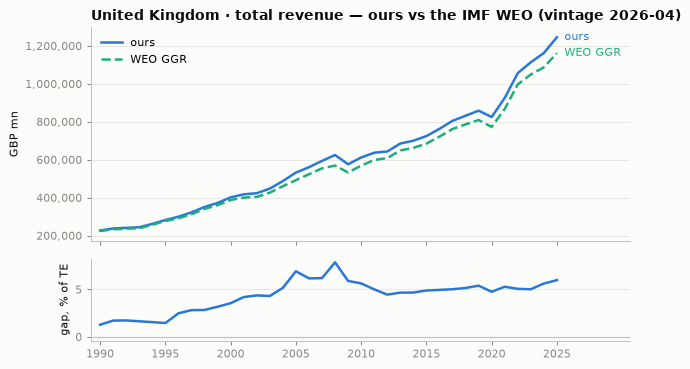

overlap 1990-2025; gap mean +4.355% of TE, sigma 1.662, range +1.281 to +7.849; classified: perimeter, unexplained


In [89]:
weo_chart("GBR", "revenue")

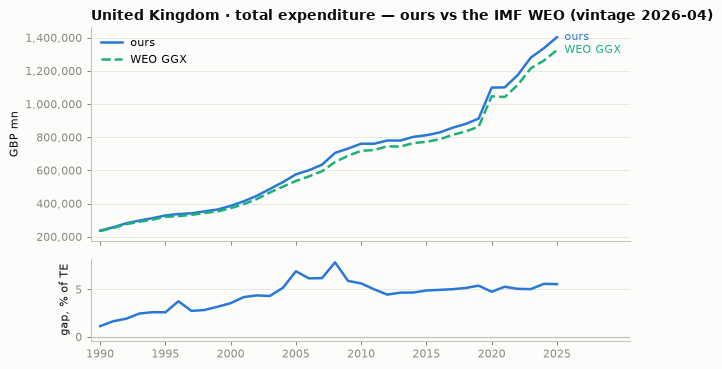

overlap 1990-2025; gap mean +4.458% of TE, sigma 1.500, range +1.130 to +7.849; classified: perimeter, unexplained


In [90]:
weo_chart("GBR", "expenditure")

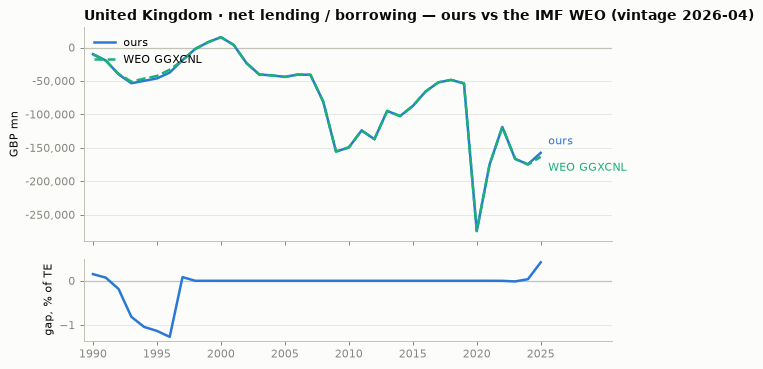

overlap 1990-2025; gap mean -0.103% of TE, sigma 0.358, range -1.267 to +0.417; classified: perimeter, unexplained


In [91]:
weo_chart("GBR", "nlb")

## 4.2 France

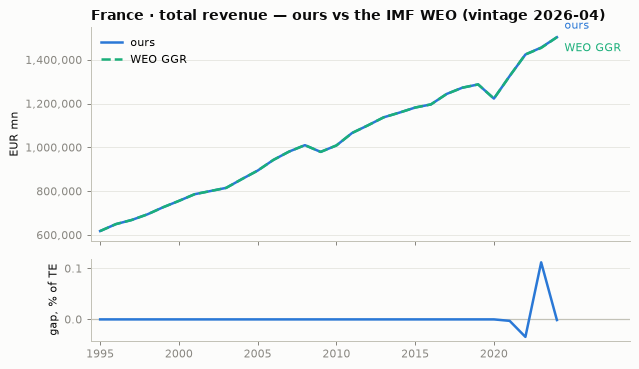

overlap 1995-2024; gap mean +0.002% of TE, sigma 0.022, range -0.034 to +0.112; classified: revision


In [92]:
weo_chart("FRA", "revenue")

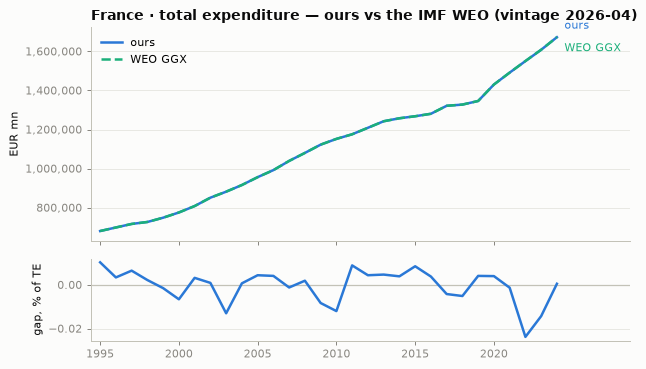

overlap 1995-2024; gap mean -0.000% of TE, sigma 0.008, range -0.024 to +0.010; classified: revision


In [93]:
weo_chart("FRA", "expenditure")

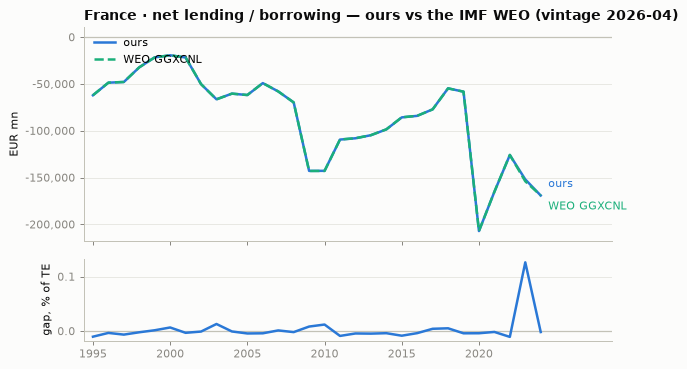

overlap 1995-2024; gap mean +0.003% of TE, sigma 0.024, range -0.011 to +0.126; classified: revision


In [94]:
weo_chart("FRA", "nlb")

## 4.3 Germany

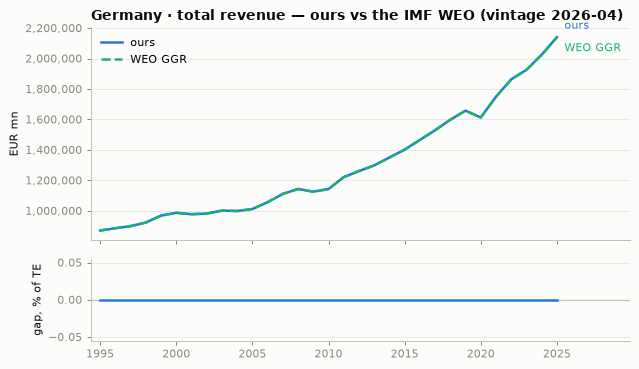

overlap 1995-2025; gap mean +0.000% of TE, sigma 0.000, range +0.000 to +0.000; classified: revision


In [95]:
weo_chart("DEU", "revenue")

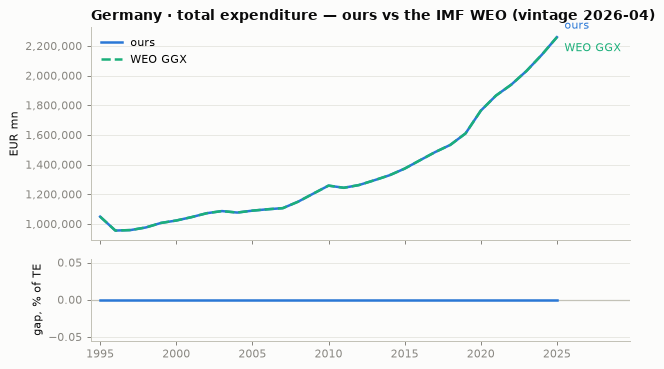

overlap 1995-2025; gap mean +0.000% of TE, sigma 0.000, range +0.000 to +0.000; classified: revision


In [96]:
weo_chart("DEU", "expenditure")

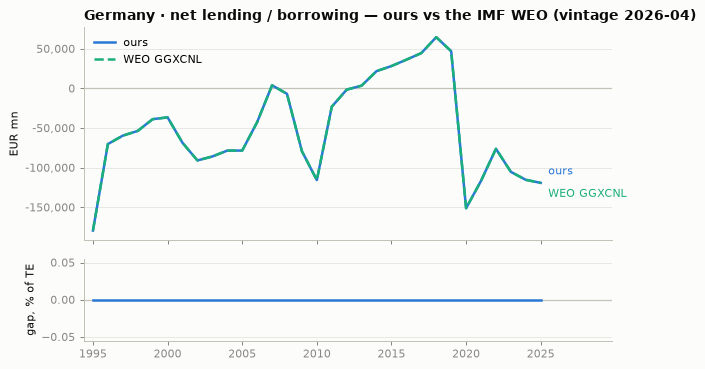

overlap 1995-2025; gap mean +0.000% of TE, sigma 0.000, range +0.000 to +0.000; classified: revision


In [97]:
weo_chart("DEU", "nlb")

## 4.4 The forecast side

Levels cannot be compared past the last outturn, so the forecast side asks a
different question: **of the change in the balance the WEO projects, how much do
our published line-level forecasts account for?** That is `explained_share` —
1.0 means fully accounted for, 0.0 means the projected move sits entirely in
residuals nobody publishes a forecast for.

A low share is a fact about the availability of official forecasts, not an error
in the data. Negative values mean the covered lines move *against* the WEO's
projected direction.

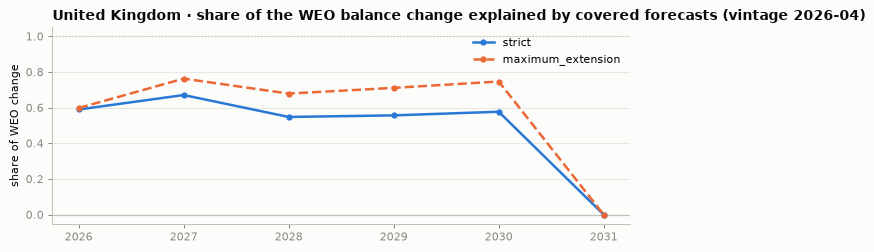

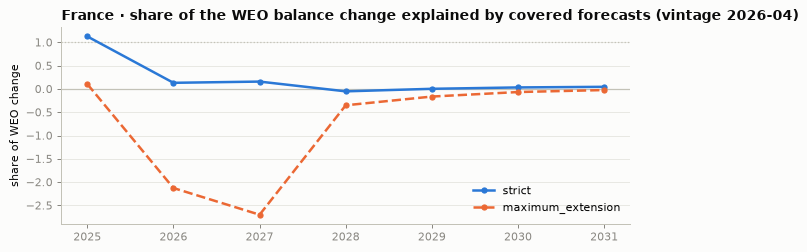

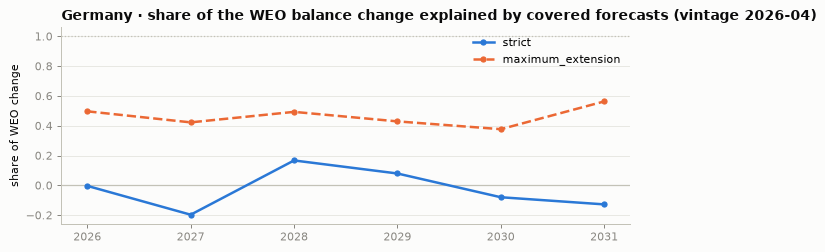

In [98]:
def explained_share(iso3, vintage=None):
    vintage = vintage or LATEST
    d = RECON.query("block == 'forecast' and component == 'explained_share' "
                    "and iso3 == @iso3 and weo_vintage == @vintage")
    fig, ax = plt.subplots()
    for variant, colour, style in (("strict", BLUE, "-"),
                                   ("maximum_extension", ORANGE, "--")):
        s = d.query("variant == @variant").sort_values("year")
        ax.plot(s.year, s.contribution_pp, color=colour, ls=style,
                marker="o", markersize=4, label=variant)
    ax.axhline(0, color=AXIS, lw=1, zorder=0)
    ax.axhline(1, color=AXIS, lw=1, ls=":", zorder=0)
    ax.set_title(f"{NAME[iso3]} · share of the WEO balance change explained "
                 f"by covered forecasts (vintage {vintage})")
    ax.set_ylabel("share of WEO change")
    ax.grid(axis="y")
    ax.legend(loc="best")
    fig.tight_layout()
    plt.show()


for iso3 in ("GBR", "FRA", "DEU"):
    explained_share(iso3)

---

# 5. The two TE numbers

Point 5 of the schema notes, charted. The COFOG tree's `TE` comes from the
expenditure anchor; the ledger's `TE` comes from the balance anchor. For France
and Germany these are the same Eurostat table and agree to rounding. For the UK
they are two different ONS tables — ESA Table 11 against the general-government
receipts-and-expenditure table — so they can and do differ.

Neither is wrong. They are different published totals, and the pipeline keeps
both rather than picking one, so which anchor a number came from stays visible.

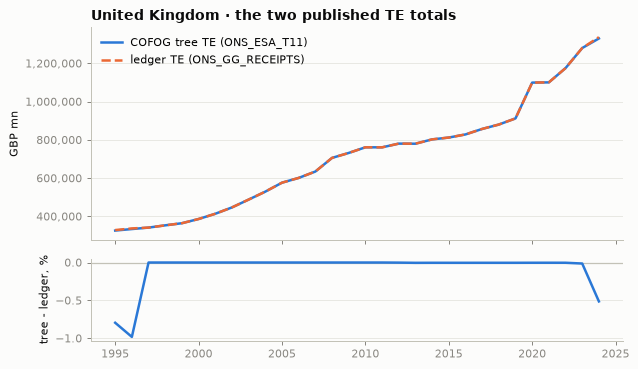

worst absolute difference 0.9808% in 1996


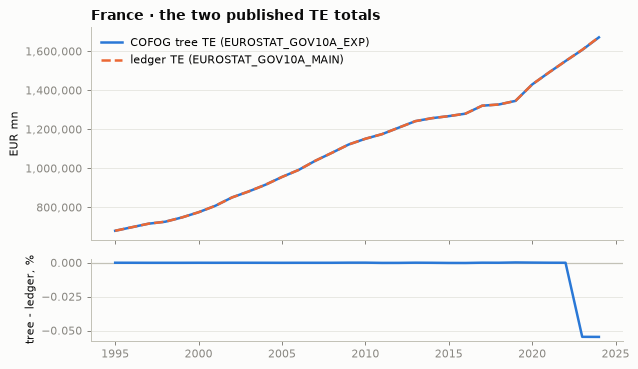

worst absolute difference 0.0547% in 2024


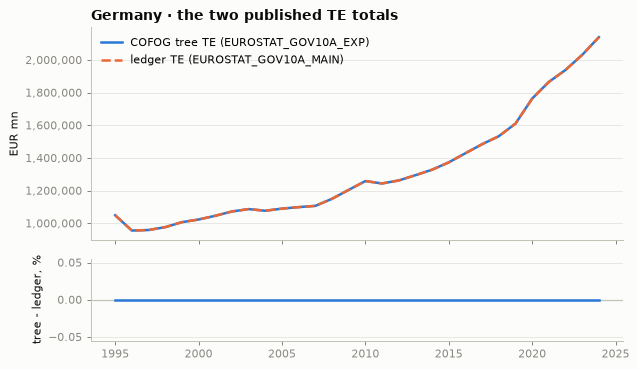

worst absolute difference 0.0000% in 1995


In [99]:
def te_compare(iso3):
    tree = (TREE.query("iso3 == @iso3 and line_code == 'TE' and "
                       "variant == 'strict'").sort_values("year"))
    led = LEDGER.query("iso3 == @iso3 and variant == 'strict'").sort_values("year")
    both = tree[["year", "value_lcu_mn", "source_id"]].merge(
        led[["year", "te_lcu_mn", "source_id"]], on="year",
        suffixes=("_tree", "_ledger"))
    both["diff_pct"] = 100 * (both.value_lcu_mn - both.te_lcu_mn) / both.te_lcu_mn

    fig, (ax, gx) = plt.subplots(2, 1, figsize=(7.2, 4.2), sharex=True,
                                 height_ratios=[2.6, 1])
    ax.plot(both.year, both.value_lcu_mn, color=BLUE,
            label=f"COFOG tree TE ({both.source_id_tree.iloc[0]})")
    ax.plot(both.year, both.te_lcu_mn, color=ORANGE, ls="--",
            label=f"ledger TE ({both.source_id_ledger.iloc[0]})")
    ax.set_title(f"{NAME[iso3]} · the two published TE totals")
    ax.set_ylabel(f"{tree.currency.iloc[0]} mn")
    ax.grid(axis="y")
    thousands(ax)
    ax.legend(loc="upper left")

    gx.plot(both.year, both.diff_pct, color=BLUE)
    gx.axhline(0, color=AXIS, lw=1, zorder=0)
    gx.set_ylabel("tree - ledger, %")
    gx.grid(axis="y")
    gx.margins(x=0.03)
    fig.tight_layout()
    plt.show()
    print(f"worst absolute difference {both.diff_pct.abs().max():.4f}% "
          f"in {int(both.loc[both.diff_pct.abs().idxmax(), 'year'])}")


for iso3 in ("GBR", "FRA", "DEU"):
    te_compare(iso3)

---

# 6. Where the seams are

A last pass over the whole book: every seam in every series, counted and listed,
so nothing charted above goes unnoticed. Each row is a year where a series
changes source or construction method — the dotted rules in the charts.

In [100]:
rows = []
for (iso3, line), g in TREE.query("variant == 'maximum_extension'").groupby(
        ["iso3", "line_code"]):
    for year in _seams(g):
        prev = g.query("year == @year - 1").iloc[0]
        curr = g.query("year == @year").iloc[0]
        rows.append({"iso3": iso3, "line": line, "seam_year": year,
                     "from": f"{prev.observation_type} ({prev.source_id})",
                     "to": f"{curr.observation_type} ({curr.source_id})",
                     "step_pct": round(100 * (curr.value_lcu_mn
                                              / prev.value_lcu_mn - 1), 2)})
seams = pd.DataFrame(rows).sort_values(["iso3", "line", "seam_year"])
print(f"{len(seams)} seams across {seams.groupby(['iso3', 'line']).ngroups} series")
seams.reset_index(drop=True)

73 seams across 39 series


,iso3,line,seam_year,from,to,step_pct
0,DEU,GF01,1995,stitched_actual (IMF_GFS),anchor_actual (EUROSTAT_GOV10A_EXP),6.20
1,DEU,GF01,2025,anchor_actual (EUROSTAT_GOV10A_EXP),stitched_actual (EC_AMECO),8.11
2,DEU,GF01,2026,stitched_actual (EC_AMECO),proxy_forecast (EC_AMECO),7.70
3,DEU,GF01_7,1995,stitched_actual (EC_AMECO),level2_proxy_actual (EUROSTAT_GOV10A_EXP),9.82
4,DEU,GF01_7,2000,level2_proxy_actual (EUROSTAT_GOV10A_EXP),anchor_actual (EUROSTAT_GOV10A_EXP),11.21
...,...,...,...,...,...,...
68,GBR,R04,2026,anchor_actual (ONS_GG_RECEIPTS),composite_forecast (OBR_EFO_LATEST),2.94
69,GBR,R05,2026,derived_actual (ONS_GG_RECEIPTS),composite_forecast (OBR_EFO_LATEST),6.54
70,GBR,R06,1990,stitched_actual (OECD_RS),anchor_actual (ONS_GG_RECEIPTS),5.75
71,GBR,R06,2026,anchor_actual (ONS_GG_RECEIPTS),direct_forecast (EC_AMECO),4.00


`step_pct` is the year-on-year change *across* the seam. It is not an error
term — spending and revenue really do change from year to year — but an
outsized value at a seam is the first place to look if a series seems wrong. Sort
by it to triage:

In [101]:
seams.reindex(seams.step_pct.abs().sort_values(ascending=False).index).head(15)

,iso3,line,seam_year,from,to,step_pct
10,DEU,GF04,1995,stitched_actual (IMF_GFS),anchor_actual (EUROSTAT_GOV10A_EXP),141.04
15,DEU,GF08,1995,stitched_actual (IMF_GFS),anchor_actual (EUROSTAT_GOV10A_EXP),38.67
65,GBR,R03,1990,stitched_actual (OECD_RS),anchor_actual (ONS_GG_RECEIPTS),22.57
34,FRA,GF01,2026,stitched_actual (EC_AMECO),proxy_forecast (EC_AMECO),19.04
37,FRA,GF01_7,2026,stitched_actual (EC_AMECO),direct_forecast (EC_AMECO),19.04
55,GBR,GF01_7,2025,anchor_actual (ONS_ESA_T11),stitched_actual (EC_AMECO),18.81
51,GBR,GF01,2025,anchor_actual (ONS_ESA_T11),stitched_actual (EC_AMECO),18.81
7,DEU,GF01_7,2028,direct_forecast (EC_AMECO),direct_forecast (EC_DSM),15.99
54,GBR,GF01_7,1995,stitched_actual (ONS_PSF_INTEREST),anchor_actual (ONS_ESA_T11),14.67
67,GBR,R04,1990,stitched_actual (OECD_RS),anchor_actual (ONS_GG_RECEIPTS),-14.35
